<a href="https://colab.research.google.com/github/yordanET/ComportamientoEstudiante/blob/main/Entrenamiento_Modelo_Comportamiento_TFLite_COLAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrenamiento del modelo de comportamiento estudiantil con TensorFlow Lite

Este cuaderno entrena **únicamente el modelo de comportamiento estudiantil**.  
No contiene los modelos de atención ni de estados emocionales.

## Clases del modelo

| ID | Clase | Descripción |
|---:|---|---|
| 0 | `read` | El estudiante está leyendo |
| 1 | `write` | El estudiante está escribiendo |
| 2 | `lookup` | El estudiante mira hacia arriba o al frente |
| 3 | `raise_hand` | El estudiante levanta la mano |
| 4 | `turn_head` | El estudiante gira la cabeza |
| 5 | `stand` | El estudiante está de pie |
| 6 | `discuss` | El estudiante conversa o participa en una discusión |

## Flujo del cuaderno

1. Configuración de Google Colab y Google Drive.
2. Descarga o reutilización de SCBehavior.
3. Incorporación opcional y controlada de SCB-Dataset5.
4. Auditoría de etiquetas y prevención de fuga de datos.
5. Generación de recortes individuales de estudiantes.
6. Comparación entre MobileNetV2, MobileNetV3Small y EfficientNetB0.
7. Entrenamiento inicial y ajuste fino.
8. Evaluación predictiva.
9. Conversión a TensorFlow Lite.
10. Evaluación de latencia, FPS, CPU, RAM y tamaño.
11. Selección y exportación del modelo final.

# 00. Correspondencia con la operacionalización

| Dimensión | Indicador | Subindicador | Escala |
|---|---|---|---|
| Desempeño del modelo TensorFlow Lite | Accuracy | Proporción global de predicciones correctas | Razón (%) |
| Desempeño del modelo TensorFlow Lite | Precisión macro | Promedio de la precisión entre las clases | Razón (%) |
| Desempeño del modelo TensorFlow Lite | Recall macro | Promedio de la sensibilidad entre las clases | Razón (%) |
| Desempeño del modelo TensorFlow Lite | F1-Score macro | Desempeño equilibrado entre precisión y recall | Razón (%) |
| Desempeño del modelo TensorFlow Lite | MCC | Correlación global ante posible desbalance | Intervalo (-1 a 1) |
| Rendimiento computacional | Tiempo de inferencia | Tiempo promedio por imagen | Razón (ms) |
| Rendimiento computacional | Velocidad de procesamiento | Imágenes o fotogramas procesados por segundo | Razón (FPS) |
| Rendimiento computacional | Uso del procesador | Utilización media del CPU durante la inferencia | Razón (%) |
| Rendimiento computacional | Uso de memoria RAM | Memoria RAM utilizada durante la inferencia | Razón (MB) |
| Rendimiento computacional | Tamaño del modelo | Espacio ocupado por el archivo TensorFlow Lite | Razón (MB) |

También se calcula **Balanced Accuracy** y **F1 weighted** como métricas complementarias para detectar resultados engañosos cuando existen clases desbalanceadas.

# 01. Instalación de dependencias

In [ ]:
%pip install -q \
    "huggingface_hub>=0.26" \
    "iterative-stratification>=0.1.9" \
    "psutil>=5.9" \
    "pyyaml>=6.0" \
    "openpyxl>=3.1"

In [ ]:
# Git LFS se utiliza cuando SCBehavior debe descargarse desde GitHub.
!apt-get update -qq
!apt-get install -y -qq git-lfs
!git lfs install

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Git LFS initialized.


# 02. Importación de librerías

In [ ]:
import gc
import hashlib
import json
import math
import os
import random
import re
import shutil
import subprocess
import sys
import time
import zipfile

from datetime import datetime
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import tensorflow as tf
import yaml

from IPython.display import display
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow: 2.20.0
OpenCV: 4.13.0


# 03. Reproducibilidad y GPU

In [ ]:
SEMILLA = 42

os.environ["PYTHONHASHSEED"] = str(SEMILLA)
random.seed(SEMILLA)
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

GPUS = tf.config.list_physical_devices("GPU")

if GPUS:
    for gpu in GPUS:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except Exception:
            pass

    try:
        keras.mixed_precision.set_global_policy("mixed_float16")
        print("Precisión mixta activada.")
    except Exception as error:
        print("No se pudo activar precisión mixta:", error)
else:
    print("No se detectó GPU. El cuaderno puede ejecutarse en CPU, pero será más lento.")

print("Dispositivos GPU:", GPUS)

Precisión mixta activada.
Dispositivos GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 04. Google Drive y estructura del proyecto

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
RUTA_PROYECTO = Path(
    "/content/drive/MyDrive/"
    "Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento"
)

CARPETAS = {
    "raw": RUTA_PROYECTO / "datasets" / "raw",
    "processed": RUTA_PROYECTO / "datasets" / "processed",
    "recortes": RUTA_PROYECTO / "datasets" / "processed" / "recortes",
    "manifiestos": RUTA_PROYECTO / "datasets" / "processed" / "manifiestos",
    "modelos": RUTA_PROYECTO / "modelos",
    "checkpoints": RUTA_PROYECTO / "modelos" / "checkpoints",
    "tflite": RUTA_PROYECTO / "modelos" / "tflite",
    "metricas": RUTA_PROYECTO / "resultados" / "metricas",
    "graficos": RUTA_PROYECTO / "resultados" / "graficos",
    "reportes": RUTA_PROYECTO / "resultados" / "reportes",
    "exportacion": RUTA_PROYECTO / "exportacion_final",
}

for ruta in CARPETAS.values():
    ruta.mkdir(parents=True, exist_ok=True)

print("Proyecto:", RUTA_PROYECTO)
for nombre, ruta in CARPETAS.items():
    print(f"{nombre:<12}: {ruta}")

Proyecto: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento
raw         : /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/raw
processed   : /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/processed
recortes    : /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/processed/recortes
manifiestos : /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/processed/manifiestos
modelos     : /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos
checkpoints : /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/checkpoints
tflite      : /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/tflite
metricas    : /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/resultados/metr

# 05. Configuración general

In [ ]:
CONFIGURACION = {
    "clases": [
        "read",
        "write",
        "lookup",
        "raise_hand",
        "turn_head",
        "stand",
        "discuss",
    ],
    "imagen": {
        "alto": 224,
        "ancho": 224,
        "canales": 3,
    },
    "division": {
        "train": 0.70,
        "val": 0.15,
        "test": 0.15,
    },
    "dataset": {
        "reutilizar_proyectos_anteriores": True,
        "clonar_scbehavior_si_falta": True,
        "usar_scb_dataset5": True,
        "descargar_scb_dataset5_si_falta": True,
        "paquetes_scb5": [
            "handrise_read_write",
            "discuss",
            "bow_turn_head",
        ],
        "scb5_solo_train": True,
        "max_ratio_scb5_sobre_scbehavior_por_clase": 1.0,
        "regenerar_recortes": False,
        "margen_recorte": 0.08,
        "tamano_minimo_recorte": 24,
    },
    "entrenamiento": {
        "batch_size": 32,
        "epocas_comparacion": 4,
        "epocas_cabeza": 15,
        "epocas_fine_tuning": 10,
        "learning_rate": 1e-3,
        "fine_tune_learning_rate": 2e-5,
        "dropout": 0.35,
        "ultimas_capas_entrenables": 35,
        "paciencia": 4,
        "usar_pesos_clase": True,
        "max_peso_clase": 3.0,
    },
    "arquitecturas": {
        "comparar": True,
        "candidatas": [
            "MobileNetV2",
            "MobileNetV3Small",
            "EfficientNetB0",
        ],
        "predeterminada": "EfficientNetB0",
    },
    "evaluacion": {
        "f1_macro_aceptable": 0.70,
        "mcc_aceptable": 0.50,
        "balanced_accuracy_aceptable": 0.70,
        "perdida_maxima_tflite": 0.03,
        "muestras_benchmark": 300,
    },
}

CLASES = CONFIGURACION["clases"]
NUMERO_CLASES = len(CLASES)
TAMANO_IMAGEN = (
    CONFIGURACION["imagen"]["alto"],
    CONFIGURACION["imagen"]["ancho"],
)
BATCH_SIZE = int(CONFIGURACION["entrenamiento"]["batch_size"])
AUTOTUNE = tf.data.AUTOTUNE

RUTA_CONFIGURACION = CARPETAS["reportes"] / "configuracion_entrenamiento.json"
RUTA_CONFIGURACION.write_text(
    json.dumps(CONFIGURACION, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print(json.dumps(CONFIGURACION, indent=2, ensure_ascii=False))

{
  "clases": [
    "read",
    "write",
    "lookup",
    "raise_hand",
    "turn_head",
    "stand",
    "discuss"
  ],
  "imagen": {
    "alto": 224,
    "ancho": 224,
    "canales": 3
  },
  "division": {
    "train": 0.7,
    "val": 0.15,
    "test": 0.15
  },
  "dataset": {
    "reutilizar_proyectos_anteriores": true,
    "clonar_scbehavior_si_falta": true,
    "usar_scb_dataset5": true,
    "descargar_scb_dataset5_si_falta": true,
    "paquetes_scb5": [
      "handrise_read_write",
      "discuss",
      "bow_turn_head"
    ],
    "scb5_solo_train": true,
    "max_ratio_scb5_sobre_scbehavior_por_clase": 1.0,
    "regenerar_recortes": false,
    "margen_recorte": 0.08,
    "tamano_minimo_recorte": 24
  },
  "entrenamiento": {
    "batch_size": 32,
    "epocas_comparacion": 4,
    "epocas_cabeza": 15,
    "epocas_fine_tuning": 10,
    "learning_rate": 0.001,
    "fine_tune_learning_rate": 2e-05,
    "dropout": 0.35,
    "ultimas_capas_entrenables": 35,
    "paciencia": 4,
    "usa

# 06. Utilidades generales

In [ ]:
EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def ejecutar_comando(comando, descripcion=""):
    if descripcion:
        print(descripcion)

    resultado = subprocess.run(
        comando,
        check=False,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    print(resultado.stdout)

    if resultado.returncode != 0:
        raise RuntimeError(
            f"El comando falló con código {resultado.returncode}: {comando}"
        )


def extraer_zip_seguro(ruta_zip: Path, destino: Path):
    destino.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ruta_zip, "r") as archivo:
        for miembro in archivo.infolist():
            ruta_final = (destino / miembro.filename).resolve()

            if not str(ruta_final).startswith(str(destino.resolve())):
                raise RuntimeError(
                    f"Ruta insegura dentro del ZIP: {miembro.filename}"
                )

        archivo.extractall(destino)


def tiene_imagenes_y_etiquetas(ruta: Path) -> bool:
    if ruta is None or not Path(ruta).exists():
        return False

    tiene_imagen = any(
        archivo.is_file() and archivo.suffix.lower() in EXTENSIONES_IMAGEN
        for archivo in Path(ruta).rglob("*")
    )

    tiene_txt = any(
        archivo.is_file() and archivo.suffix.lower() == ".txt"
        for archivo in Path(ruta).rglob("*")
    )

    return tiene_imagen and tiene_txt


def seleccionar_primera_ruta_valida(candidatas):
    for ruta in candidatas:
        ruta = Path(ruta)

        if tiene_imagenes_y_etiquetas(ruta):
            return ruta

    return None


def distancia_rutas(ruta_a: Path, ruta_b: Path) -> int:
    partes_a = ruta_a.parts
    partes_b = ruta_b.parts
    comunes = 0

    for parte_a, parte_b in zip(partes_a, partes_b):
        if parte_a != parte_b:
            break
        comunes += 1

    return len(partes_a) + len(partes_b) - 2 * comunes


def hash_texto(texto: str, longitud: int = 20) -> str:
    return hashlib.sha256(
        str(texto).encode("utf-8")
    ).hexdigest()[:longitud]


def guardar_json(contenido, ruta: Path):
    ruta.parent.mkdir(parents=True, exist_ok=True)
    ruta.write_text(
        json.dumps(contenido, indent=2, ensure_ascii=False, default=str),
        encoding="utf-8",
    )


def listar_tamano(ruta: Path) -> float:
    return ruta.stat().st_size / (1024 ** 2)

# 07. Localización o descarga de SCBehavior

In [ ]:
RUTA_SCB_RAW = CARPETAS["raw"] / "SCBehavior"
RUTA_SCB_EXTRAIDO = CARPETAS["processed"] / "SCBehavior_extraido"
RUTA_SCB_TEMPORAL = Path("/content/SCBehavior_repo")

RUTAS_SCB_ANTERIORES = [
    Path(
        "/content/drive/MyDrive/"
        "Proyecto_Comportamiento_Estudiantil_2/"
        "datasets/processed/SCBehavior/dataset_extraido"
    ),
    Path(
        "/content/drive/MyDrive/"
        "Proyecto_Comportamiento_Estudiantil_2/"
        "datasets/raw/SCBehavior"
    ),
    Path(
        "/content/drive/MyDrive/"
        "Proyecto_Comportamiento_Estudiantil/"
        "datasets/processed/SCBehavior/dataset_extraido"
    ),
    Path(
        "/content/drive/MyDrive/"
        "Proyecto_Comportamiento_Estudiantil/"
        "datasets/raw/SCBehavior"
    ),
]

RUTA_SCB_RAW.mkdir(parents=True, exist_ok=True)
RUTA_SCB_EXTRAIDO.mkdir(parents=True, exist_ok=True)

for ruta_zip in sorted(RUTA_SCB_RAW.rglob("*.zip")):
    print("Extrayendo:", ruta_zip)
    extraer_zip_seguro(ruta_zip, RUTA_SCB_EXTRAIDO)

candidatas_scb = [
    RUTA_SCB_EXTRAIDO,
    RUTA_SCB_RAW,
]

if CONFIGURACION["dataset"]["reutilizar_proyectos_anteriores"]:
    candidatas_scb.extend(RUTAS_SCB_ANTERIORES)

RUTA_SCB_TRABAJO = seleccionar_primera_ruta_valida(candidatas_scb)

if (
    RUTA_SCB_TRABAJO is None
    and CONFIGURACION["dataset"]["clonar_scbehavior_si_falta"]
):
    if RUTA_SCB_TEMPORAL.exists():
        shutil.rmtree(RUTA_SCB_TEMPORAL)

    ejecutar_comando(
        [
            "git",
            "clone",
            "--depth",
            "1",
            "https://github.com/CCNUZFW/SCBehavior.git",
            str(RUTA_SCB_TEMPORAL),
        ],
        "Clonando SCBehavior...",
    )

    ejecutar_comando(
        [
            "git",
            "-C",
            str(RUTA_SCB_TEMPORAL),
            "lfs",
            "pull",
        ],
        "Descargando archivos de Git LFS...",
    )

    RUTA_SCB_TRABAJO = seleccionar_primera_ruta_valida(
        [RUTA_SCB_TEMPORAL]
    )

if RUTA_SCB_TRABAJO is None:
    raise RuntimeError(
        "No se encontró SCBehavior. Coloca un ZIP o el dataset extraído en: "
        f"{RUTA_SCB_RAW}"
    )

print("SCBehavior localizado en:")
print(RUTA_SCB_TRABAJO)

Clonando SCBehavior...
Cloning into '/content/SCBehavior_repo'...
https://git-lfs.github.com/spec/v1 is not a valid attribute name: .gitattributes:1
sha256:da82a15e13b7163aef0def74f6e4e6fc5d1531269562e557084403ff032e62fb is not a valid attribute name: .gitattributes:2

Descargando archivos de Git LFS...

SCBehavior localizado en:
/content/SCBehavior_repo


# 08. Descarga opcional y controlada de SCB-Dataset5

In [ ]:
from huggingface_hub import hf_hub_download, list_repo_files

RUTA_SCB5_RAW = CARPETAS["raw"] / "SCB_Dataset5"
RUTA_SCB5_EXTRAIDO = CARPETAS["processed"] / "SCB_Dataset5_extraido"

RUTAS_SCB5_ANTERIORES = [
    Path(
        "/content/drive/MyDrive/"
        "Proyecto_Comportamiento_Estudiantil_2/"
        "datasets/processed/SCB_Dataset5/dataset_extraido"
    ),
    Path(
        "/content/drive/MyDrive/"
        "Proyecto_Comportamiento_Estudiantil_2/"
        "datasets/raw/SCB_Dataset5"
    ),
]

RUTA_SCB5_RAW.mkdir(parents=True, exist_ok=True)
RUTA_SCB5_EXTRAIDO.mkdir(parents=True, exist_ok=True)

USAR_SCB5 = bool(
    CONFIGURACION["dataset"]["usar_scb_dataset5"]
)

RUTA_SCB5_TRABAJO = None

if USAR_SCB5:
    candidatas_scb5 = [
        RUTA_SCB5_EXTRAIDO,
        RUTA_SCB5_RAW,
    ]

    if CONFIGURACION["dataset"]["reutilizar_proyectos_anteriores"]:
        candidatas_scb5.extend(RUTAS_SCB5_ANTERIORES)

    RUTA_SCB5_TRABAJO = seleccionar_primera_ruta_valida(
        candidatas_scb5
    )

    if (
        RUTA_SCB5_TRABAJO is None
        and CONFIGURACION["dataset"]["descargar_scb_dataset5_si_falta"]
    ):
        repo_id = "wintonYF/SCB-Dataset"
        archivos_repo = list_repo_files(
            repo_id=repo_id,
            repo_type="dataset",
        )

        patrones = {
            "handrise_read_write": ["handrise", "read", "write"],
            "discuss": ["discuss"],
            "bow_turn_head": ["bowturnhead"],
        }

        paquetes_activos = set(
            CONFIGURACION["dataset"]["paquetes_scb5"]
        )

        archivos_zip = [
            archivo
            for archivo in archivos_repo
            if archivo.lower().endswith(".zip")
        ]

        paquetes_encontrados = {}

        for nombre_paquete, tokens in patrones.items():
            if nombre_paquete not in paquetes_activos:
                continue

            candidatos = []

            for archivo in archivos_zip:
                normalizado = re.sub(
                    r"[^a-z0-9]+",
                    "",
                    archivo.lower(),
                )

                if all(token in normalizado for token in tokens):
                    candidatos.append(archivo)

            if candidatos:
                candidatos.sort(key=lambda valor: (len(valor), valor))
                paquetes_encontrados[nombre_paquete] = candidatos[0]

        print("Paquetes SCB-Dataset5 encontrados:")
        for nombre, archivo in paquetes_encontrados.items():
            print(f"- {nombre}: {archivo}")

        for nombre, archivo in paquetes_encontrados.items():
            ruta_descargada = hf_hub_download(
                repo_id=repo_id,
                repo_type="dataset",
                filename=archivo,
                local_dir=RUTA_SCB5_RAW,
            )

            print("Descargado:", ruta_descargada)

        for ruta_zip in sorted(RUTA_SCB5_RAW.rglob("*.zip")):
            destino = RUTA_SCB5_EXTRAIDO / ruta_zip.stem
            destino.mkdir(parents=True, exist_ok=True)

            marcador = destino / ".extraccion_completa"

            if not marcador.exists():
                print("Extrayendo:", ruta_zip)
                extraer_zip_seguro(ruta_zip, destino)
                marcador.write_text("ok", encoding="utf-8")

        RUTA_SCB5_TRABAJO = seleccionar_primera_ruta_valida(
            [RUTA_SCB5_EXTRAIDO]
        )

    if RUTA_SCB5_TRABAJO is None:
        print(
            "SCB-Dataset5 no está disponible. "
            "Se continuará únicamente con SCBehavior."
        )
        USAR_SCB5 = False
else:
    print("SCB-Dataset5 desactivado.")

print("Ruta SCB-Dataset5:", RUTA_SCB5_TRABAJO)

Paquetes SCB-Dataset5 encontrados:
- handrise_read_write: SCB5-Handrise-Read-write-2024-9-17/SCB5-Handrise-Read-write-2024-9-17.zip
- discuss: SCB5-Discuss-2024-9-17/SCB5-Discuss-2024-9-17.zip
- bow_turn_head: SCB_BowTurnHead_20250509/SCB_BowTurnHead_20250509.zip


SCB5-Handrise-Read-write-2024-9-17/SCB5-(…): reconstructing file:   0%|          |  0.00B /  779MB            

SCB5-Handrise-Read-write-2024-9-17/SCB5-(…): downloading bytes:           |  0.00B            

Descargado: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/raw/SCB_Dataset5/SCB5-Handrise-Read-write-2024-9-17/SCB5-Handrise-Read-write-2024-9-17.zip


SCB5-Discuss-2024-9-17/SCB5-Discuss-2024(…): reconstructing file:   0%|          |  0.00B /  122MB            

SCB5-Discuss-2024-9-17/SCB5-Discuss-2024(…): downloading bytes:           |  0.00B            

Descargado: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/raw/SCB_Dataset5/SCB5-Discuss-2024-9-17/SCB5-Discuss-2024-9-17.zip


SCB_BowTurnHead_20250509/SCB_BowTurnHead(…): reconstructing file:   0%|          |  0.00B /  315MB            

SCB_BowTurnHead_20250509/SCB_BowTurnHead(…): downloading bytes:           |  0.00B            

Descargado: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/raw/SCB_Dataset5/SCB_BowTurnHead_20250509/SCB_BowTurnHead_20250509.zip
Extrayendo: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/raw/SCB_Dataset5/SCB5-Discuss-2024-9-17/SCB5-Discuss-2024-9-17.zip
Extrayendo: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/raw/SCB_Dataset5/SCB5-Handrise-Read-write-2024-9-17/SCB5-Handrise-Read-write-2024-9-17.zip
Extrayendo: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/raw/SCB_Dataset5/SCB_BowTurnHead_20250509/SCB_BowTurnHead_20250509.zip
Ruta SCB-Dataset5: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/processed/SCB_Dataset5_extraido


# 09. Armonización de clases y lectura de esquemas YOLO

In [ ]:
def normalizar_etiqueta(texto: str) -> str:
    return re.sub(
        r"[^a-z0-9]+",
        "",
        str(texto).lower(),
    )


SINONIMOS = {
    "read": {"read", "reading"},
    "write": {"write", "writing"},
    "lookup": {"lookup", "lookuparound", "lookforward", "lookingup"},
    "raise_hand": {
        "raisehand",
        "raisinghand",
        "handraise",
        "handraising",
        "handrise",
        "handrising",
    },
    "turn_head": {"turnhead", "headturn", "turninghead"},
    "stand": {"stand", "standing"},
    "discuss": {"discuss", "discussion", "talk", "talking"},
}

MAPA_SINONIMOS = {}

for clase_canonica, sinonimos in SINONIMOS.items():
    MAPA_SINONIMOS[normalizar_etiqueta(clase_canonica)] = clase_canonica

    for sinonimo in sinonimos:
        MAPA_SINONIMOS[normalizar_etiqueta(sinonimo)] = clase_canonica


def armonizar_clase(nombre_original: str):
    normalizada = normalizar_etiqueta(nombre_original)

    if normalizada in {
        "bowhead",
        "headbow",
        "bowinghead",
    }:
        return None

    return MAPA_SINONIMOS.get(normalizada)


def normalizar_names_yaml(names):
    if isinstance(names, list):
        return {
            int(indice): str(nombre)
            for indice, nombre in enumerate(names)
        }

    if isinstance(names, dict):
        resultado = {}

        for clave, valor in names.items():
            try:
                resultado[int(clave)] = str(valor)
            except Exception:
                continue

        return resultado

    return {}


def cargar_esquemas_yolo(ruta_raiz: Path):
    esquemas = []

    if ruta_raiz is None or not Path(ruta_raiz).exists():
        return esquemas

    archivos_yaml = sorted(
        list(Path(ruta_raiz).rglob("data.yaml"))
        + list(Path(ruta_raiz).rglob("dataset.yaml"))
    )

    for archivo_yaml in archivos_yaml:
        try:
            contenido = yaml.safe_load(
                archivo_yaml.read_text(
                    encoding="utf-8",
                    errors="ignore",
                )
            ) or {}
        except Exception:
            continue

        nombres = normalizar_names_yaml(
            contenido.get("names")
        )

        if nombres:
            esquemas.append(
                {
                    "yaml": archivo_yaml,
                    "raiz": archivo_yaml.parent,
                    "names": nombres,
                }
            )

    return esquemas


def esquema_mas_cercano(ruta: Path, esquemas):
    candidatos = []

    for esquema in esquemas:
        raiz = Path(esquema["raiz"])

        try:
            ruta.relative_to(raiz)
            candidatos.append(esquema)
        except ValueError:
            continue

    if candidatos:
        candidatos.sort(
            key=lambda esquema: len(
                Path(esquema["raiz"]).parts
            ),
            reverse=True,
        )
        return candidatos[0]

    if esquemas:
        return min(
            esquemas,
            key=lambda esquema: distancia_rutas(
                ruta.parent,
                Path(esquema["raiz"]),
            ),
        )

    return None


ESQUEMAS_SCB = cargar_esquemas_yolo(
    RUTA_SCB_TRABAJO
)

ESQUEMAS_SCB5 = cargar_esquemas_yolo(
    RUTA_SCB5_TRABAJO
) if USAR_SCB5 else []

print("Esquemas SCBehavior:", len(ESQUEMAS_SCB))
print("Esquemas SCB-Dataset5:", len(ESQUEMAS_SCB5))

if ESQUEMAS_SCB:
    for esquema in ESQUEMAS_SCB[:3]:
        print(esquema["yaml"], esquema["names"])
else:
    print(
        "Advertencia: SCBehavior no tiene YAML detectable. "
        "Se utilizará el orden fijo de las siete clases."
    )

Esquemas SCBehavior: 0
Esquemas SCB-Dataset5: 0
Advertencia: SCBehavior no tiene YAML detectable. Se utilizará el orden fijo de las siete clases.


# 10. Creación del manifiesto de SCBehavior

In [ ]:
def construir_indice_imagenes(ruta_raiz: Path):
    indice = {}

    for archivo in Path(ruta_raiz).rglob("*"):
        if (
            archivo.is_file()
            and archivo.suffix.lower() in EXTENSIONES_IMAGEN
        ):
            indice.setdefault(
                archivo.stem,
                [],
            ).append(archivo)

    return indice


def localizar_imagen_para_label(
    label_path: Path,
    indice_imagenes,
):
    candidatos = indice_imagenes.get(
        label_path.stem,
        [],
    )

    if not candidatos:
        return None

    candidatos = sorted(
        candidatos,
        key=lambda ruta: distancia_rutas(
            label_path.parent,
            ruta.parent,
        ),
    )

    return candidatos[0]


def leer_anotaciones_yolo(label_path: Path):
    anotaciones = []

    try:
        lineas = label_path.read_text(
            encoding="utf-8",
            errors="ignore",
        ).splitlines()
    except Exception:
        return anotaciones

    for linea in lineas:
        partes = linea.strip().split()

        if len(partes) < 5:
            continue

        try:
            clase_id = int(float(partes[0]))
            xc, yc, ancho, alto = map(
                float,
                partes[1:5],
            )
        except Exception:
            continue

        valores = np.asarray(
            [xc, yc, ancho, alto],
            dtype=np.float32,
        )

        if (
            not np.isfinite(valores).all()
            or ancho <= 0
            or alto <= 0
        ):
            continue

        anotaciones.append(
            {
                "clase_id_original": clase_id,
                "xc": xc,
                "yc": yc,
                "ancho": ancho,
                "alto": alto,
            }
        )

    return anotaciones


def mapa_clases_para_label(
    label_path: Path,
    esquemas,
    usar_orden_fijo=False,
):
    esquema = esquema_mas_cercano(
        label_path,
        esquemas,
    )

    if esquema is not None:
        return esquema["names"]

    if usar_orden_fijo:
        return {
            indice: clase
            for indice, clase in enumerate(CLASES)
        }

    return {}


def construir_manifest_scbehavior(
    ruta_raiz: Path,
    esquemas,
):
    indice_imagenes = construir_indice_imagenes(
        ruta_raiz
    )

    registros = []

    for label_path in sorted(
        Path(ruta_raiz).rglob("*.txt")
    ):
        anotaciones = leer_anotaciones_yolo(
            label_path
        )

        if not anotaciones:
            continue

        imagen_path = localizar_imagen_para_label(
            label_path,
            indice_imagenes,
        )

        if imagen_path is None:
            continue

        mapa_nombres = mapa_clases_para_label(
            label_path,
            esquemas,
            usar_orden_fijo=True,
        )

        clases_presentes = []
        cantidad_objetos_validos = 0

        for anotacion in anotaciones:
            nombre_original = mapa_nombres.get(
                anotacion["clase_id_original"]
            )

            if nombre_original is None:
                continue

            clase = armonizar_clase(
                nombre_original
            )

            if clase in CLASES:
                clases_presentes.append(clase)
                cantidad_objetos_validos += 1

        if not clases_presentes:
            continue

        registro = {
            "id_imagen": hash_texto(
                str(imagen_path.resolve()),
                longitud=24,
            ),
            "imagen_path": str(imagen_path),
            "label_path": str(label_path),
            "cantidad_objetos": cantidad_objetos_validos,
        }

        for clase in CLASES:
            registro[clase] = int(
                clase in clases_presentes
            )

        registros.append(registro)

    dataframe = pd.DataFrame(registros)

    if dataframe.empty:
        raise RuntimeError(
            "No se pudo construir el manifiesto de SCBehavior. "
            "Revisa la ruta, las imágenes, los TXT y el orden de clases."
        )

    dataframe = (
        dataframe
        .drop_duplicates(
            subset=["imagen_path", "label_path"]
        )
        .reset_index(drop=True)
    )

    return dataframe


RUTA_MANIFEST_SCB_IMAGENES = (
    CARPETAS["manifiestos"]
    / "manifest_scbehavior_imagenes.csv"
)

df_scb_imagenes = construir_manifest_scbehavior(
    RUTA_SCB_TRABAJO,
    ESQUEMAS_SCB,
)

df_scb_imagenes.to_csv(
    RUTA_MANIFEST_SCB_IMAGENES,
    index=False,
)

print("Imágenes SCBehavior:", len(df_scb_imagenes))
display(df_scb_imagenes.head())
display(df_scb_imagenes[CLASES].sum().to_frame("imagenes_con_clase"))

Imágenes SCBehavior: 400


,id_imagen,imagen_path,label_path,cantidad_objetos,read,write,lookup,raise_hand,turn_head,stand,discuss
0,4cbd2a503e5e89ea68a366ea,/content/SCBehavior_repo/SCBehavior_YOLO/image...,/content/SCBehavior_repo/SCBehavior_YOLO/label...,22,1,0,1,1,0,0,0
1,41d25a46a55444d225030c9a,/content/SCBehavior_repo/SCBehavior_YOLO/image...,/content/SCBehavior_repo/SCBehavior_YOLO/label...,6,0,0,0,0,0,0,1
2,5fa640eb8495c208068992cc,/content/SCBehavior_repo/SCBehavior_YOLO/image...,/content/SCBehavior_repo/SCBehavior_YOLO/label...,27,0,0,1,1,0,0,0
3,7cac4dcb7dd0c4ef5f098d6b,/content/SCBehavior_repo/SCBehavior_YOLO/image...,/content/SCBehavior_repo/SCBehavior_YOLO/label...,6,0,0,0,0,0,0,1
4,5ad39c225944ffa12f2ccbcc,/content/SCBehavior_repo/SCBehavior_YOLO/image...,/content/SCBehavior_repo/SCBehavior_YOLO/label...,6,0,0,0,0,0,0,1


,imagenes_con_clase
read,81
write,249
lookup,345
raise_hand,279
turn_head,147
stand,63
discuss,41


# 11. División estratificada a nivel de imagen

In [ ]:
def dividir_multietiqueta(
    dataframe: pd.DataFrame,
    columnas_etiquetas,
    semilla: int,
):
    dataframe = dataframe.copy().reset_index(drop=True)

    train_prop = CONFIGURACION["division"]["train"]
    val_prop = CONFIGURACION["division"]["val"]
    test_prop = CONFIGURACION["division"]["test"]

    if not math.isclose(
        train_prop + val_prop + test_prop,
        1.0,
        rel_tol=1e-6,
    ):
        raise ValueError(
            "Las proporciones train, val y test deben sumar 1."
        )

    y = dataframe[columnas_etiquetas].to_numpy(
        dtype=np.int32
    )

    x_auxiliar = np.zeros(
        (len(dataframe), 1),
        dtype=np.float32,
    )

    try:
        primera_division = MultilabelStratifiedShuffleSplit(
            n_splits=1,
            test_size=val_prop + test_prop,
            random_state=semilla,
        )

        indices_train, indices_temporal = next(
            primera_division.split(
                x_auxiliar,
                y,
            )
        )

        proporcion_test_temporal = (
            test_prop / (val_prop + test_prop)
        )

        segunda_division = MultilabelStratifiedShuffleSplit(
            n_splits=1,
            test_size=proporcion_test_temporal,
            random_state=semilla + 1,
        )

        indices_val_rel, indices_test_rel = next(
            segunda_division.split(
                x_auxiliar[indices_temporal],
                y[indices_temporal],
            )
        )

        indices_val = indices_temporal[
            indices_val_rel
        ]

        indices_test = indices_temporal[
            indices_test_rel
        ]

    except Exception as error:
        print(
            "La división multietiqueta falló. "
            "Se utilizará una división aleatoria reproducible:",
            error,
        )

        indices = np.arange(len(dataframe))
        rng = np.random.default_rng(semilla)
        rng.shuffle(indices)

        fin_train = int(len(indices) * train_prop)
        fin_val = fin_train + int(
            len(indices) * val_prop
        )

        indices_train = indices[:fin_train]
        indices_val = indices[fin_train:fin_val]
        indices_test = indices[fin_val:]

    dataframe["split"] = ""

    dataframe.loc[
        indices_train,
        "split",
    ] = "train"

    dataframe.loc[
        indices_val,
        "split",
    ] = "val"

    dataframe.loc[
        indices_test,
        "split",
    ] = "test"

    return dataframe


df_scb_imagenes = dividir_multietiqueta(
    df_scb_imagenes,
    CLASES,
    SEMILLA,
)

if (
    df_scb_imagenes["id_imagen"].duplicated().any()
    or df_scb_imagenes["split"].eq("").any()
):
    raise RuntimeError(
        "La división de SCBehavior no es válida."
    )

df_scb_imagenes.to_csv(
    RUTA_MANIFEST_SCB_IMAGENES,
    index=False,
)

print("Distribución de imágenes:")
display(
    df_scb_imagenes["split"]
    .value_counts()
    .rename_axis("split")
    .to_frame("imagenes")
)

print("Cobertura multietiqueta por split:")
display(
    df_scb_imagenes
    .groupby("split")[CLASES]
    .sum()
    .T
)

Distribución de imágenes:


,imagenes
split,
train,282
test,59
val,59


Cobertura multietiqueta por split:


split,test,train,val
read,12,57,12
write,38,174,37
lookup,53,241,51
raise_hand,42,195,42
turn_head,22,103,22
stand,9,44,10
discuss,6,29,6


# 12. Generación de recortes individuales de SCBehavior

In [ ]:
RUTA_RECORTES_SCB = (
    CARPETAS["recortes"]
    / "SCBehavior"
)

RUTA_MANIFEST_RECORTES_SCB = (
    CARPETAS["manifiestos"]
    / "manifest_recortes_scbehavior.csv"
)

REGENERAR_RECORTES = bool(
    CONFIGURACION["dataset"]["regenerar_recortes"]
)

MARGEN_RECORTE = float(
    CONFIGURACION["dataset"]["margen_recorte"]
)

TAMANO_MINIMO_RECORTE = int(
    CONFIGURACION["dataset"]["tamano_minimo_recorte"]
)


def generar_recortes_scbehavior(
    dataframe: pd.DataFrame,
    ruta_destino: Path,
):
    registros = []
    ruta_destino.mkdir(parents=True, exist_ok=True)

    for numero_fila, fila in dataframe.iterrows():
        imagen_path = Path(fila["imagen_path"])
        label_path = Path(fila["label_path"])

        imagen = cv2.imread(str(imagen_path))

        if imagen is None:
            continue

        alto_imagen, ancho_imagen = imagen.shape[:2]
        anotaciones = leer_anotaciones_yolo(
            label_path
        )

        mapa_nombres = mapa_clases_para_label(
            label_path,
            ESQUEMAS_SCB,
            usar_orden_fijo=True,
        )

        for numero_objeto, anotacion in enumerate(
            anotaciones
        ):
            nombre_original = mapa_nombres.get(
                anotacion["clase_id_original"]
            )

            if nombre_original is None:
                continue

            clase = armonizar_clase(
                nombre_original
            )

            if clase not in CLASES:
                continue

            xc = anotacion["xc"] * ancho_imagen
            yc = anotacion["yc"] * alto_imagen
            ancho_caja = anotacion["ancho"] * ancho_imagen
            alto_caja = anotacion["alto"] * alto_imagen

            margen_x = ancho_caja * MARGEN_RECORTE
            margen_y = alto_caja * MARGEN_RECORTE

            x1 = int(
                max(
                    0,
                    xc - ancho_caja / 2 - margen_x,
                )
            )
            y1 = int(
                max(
                    0,
                    yc - alto_caja / 2 - margen_y,
                )
            )
            x2 = int(
                min(
                    ancho_imagen,
                    xc + ancho_caja / 2 + margen_x,
                )
            )
            y2 = int(
                min(
                    alto_imagen,
                    yc + alto_caja / 2 + margen_y,
                )
            )

            if (
                x2 - x1 < TAMANO_MINIMO_RECORTE
                or y2 - y1 < TAMANO_MINIMO_RECORTE
            ):
                continue

            recorte = imagen[y1:y2, x1:x2]

            if recorte.size == 0:
                continue

            identificador = hash_texto(
                (
                    str(imagen_path.resolve())
                    + f"_{numero_objeto}_{clase}"
                ),
                longitud=24,
            )

            carpeta_clase = (
                ruta_destino
                / fila["split"]
                / clase
            )

            carpeta_clase.mkdir(
                parents=True,
                exist_ok=True,
            )

            ruta_recorte = (
                carpeta_clase
                / f"{identificador}.jpg"
            )

            if (
                not ruta_recorte.exists()
                or ruta_recorte.stat().st_size == 0
            ):
                correcto = cv2.imwrite(
                    str(ruta_recorte),
                    recorte,
                )

                if not correcto:
                    continue

            registros.append(
                {
                    "imagen_path": str(ruta_recorte),
                    "label_id": CLASES.index(clase),
                    "clase": clase,
                    "split": fila["split"],
                    "dataset_origen": "SCBehavior",
                    "grupo_origen": fila["id_imagen"],
                    "imagen_origen": str(imagen_path),
                    "label_origen": str(label_path),
                }
            )

        if (numero_fila + 1) % 250 == 0:
            print(
                f"Imágenes procesadas: "
                f"{numero_fila + 1:,}/{len(dataframe):,}"
            )

    return pd.DataFrame(registros)


if (
    RUTA_MANIFEST_RECORTES_SCB.exists()
    and not REGENERAR_RECORTES
):
    df_scb_recortes = pd.read_csv(
        RUTA_MANIFEST_RECORTES_SCB
    )

    df_scb_recortes = df_scb_recortes[
        df_scb_recortes["imagen_path"].map(
            lambda ruta: Path(str(ruta)).is_file()
        )
    ].reset_index(drop=True)

    print("Se cargó el manifiesto existente de recortes.")
else:
    if REGENERAR_RECORTES and RUTA_RECORTES_SCB.exists():
        shutil.rmtree(RUTA_RECORTES_SCB)

    df_scb_recortes = generar_recortes_scbehavior(
        df_scb_imagenes,
        RUTA_RECORTES_SCB,
    )

    df_scb_recortes.to_csv(
        RUTA_MANIFEST_RECORTES_SCB,
        index=False,
    )

if df_scb_recortes.empty:
    raise RuntimeError(
        "No se generaron recortes de SCBehavior."
    )

print("Recortes SCBehavior:", len(df_scb_recortes))
display(
    pd.crosstab(
        df_scb_recortes["clase"],
        df_scb_recortes["split"],
    ).reindex(CLASES)
)

Imágenes procesadas: 250/400
Recortes SCBehavior: 8083


split,test,train,val
clase,,,
read,58,422,99
write,137,716,168
lookup,682,3083,715
raise_hand,128,724,159
turn_head,86,467,131
stand,9,47,10
discuss,37,172,33


# 13. Generación opcional de recortes SCB-Dataset5

In [ ]:
RUTA_RECORTES_SCB5 = (
    CARPETAS["recortes"]
    / "SCB_Dataset5"
)

RUTA_MANIFEST_RECORTES_SCB5 = (
    CARPETAS["manifiestos"]
    / "manifest_recortes_scb_dataset5.csv"
)


def generar_recortes_yolo_genericos(
    ruta_raiz: Path,
    esquemas,
    ruta_destino: Path,
    dataset_origen: str,
):
    if (
        ruta_raiz is None
        or not Path(ruta_raiz).exists()
        or not esquemas
    ):
        return pd.DataFrame()

    indice_imagenes = construir_indice_imagenes(
        ruta_raiz
    )

    registros = []
    archivos_label = sorted(
        Path(ruta_raiz).rglob("*.txt")
    )

    for numero_label, label_path in enumerate(
        archivos_label,
        start=1,
    ):
        anotaciones = leer_anotaciones_yolo(
            label_path
        )

        if not anotaciones:
            continue

        imagen_path = localizar_imagen_para_label(
            label_path,
            indice_imagenes,
        )

        if imagen_path is None:
            continue

        esquema = esquema_mas_cercano(
            label_path,
            esquemas,
        )

        if esquema is None:
            continue

        imagen = cv2.imread(str(imagen_path))

        if imagen is None:
            continue

        alto_imagen, ancho_imagen = imagen.shape[:2]
        grupo_origen = hash_texto(
            str(imagen_path.resolve()),
            longitud=24,
        )

        for numero_objeto, anotacion in enumerate(
            anotaciones
        ):
            nombre_original = esquema["names"].get(
                anotacion["clase_id_original"]
            )

            if nombre_original is None:
                continue

            clase = armonizar_clase(
                nombre_original
            )

            if clase not in CLASES:
                continue

            xc = anotacion["xc"] * ancho_imagen
            yc = anotacion["yc"] * alto_imagen
            ancho_caja = anotacion["ancho"] * ancho_imagen
            alto_caja = anotacion["alto"] * alto_imagen

            margen_x = ancho_caja * MARGEN_RECORTE
            margen_y = alto_caja * MARGEN_RECORTE

            x1 = int(max(0, xc - ancho_caja / 2 - margen_x))
            y1 = int(max(0, yc - alto_caja / 2 - margen_y))
            x2 = int(min(ancho_imagen, xc + ancho_caja / 2 + margen_x))
            y2 = int(min(alto_imagen, yc + alto_caja / 2 + margen_y))

            if (
                x2 - x1 < TAMANO_MINIMO_RECORTE
                or y2 - y1 < TAMANO_MINIMO_RECORTE
            ):
                continue

            recorte = imagen[y1:y2, x1:x2]

            if recorte.size == 0:
                continue

            identificador = hash_texto(
                (
                    str(imagen_path.resolve())
                    + f"_{numero_objeto}_{clase}"
                ),
                longitud=24,
            )

            carpeta_clase = ruta_destino / clase
            carpeta_clase.mkdir(
                parents=True,
                exist_ok=True,
            )

            ruta_recorte = (
                carpeta_clase
                / f"{identificador}.jpg"
            )

            if (
                not ruta_recorte.exists()
                or ruta_recorte.stat().st_size == 0
            ):
                correcto = cv2.imwrite(
                    str(ruta_recorte),
                    recorte,
                )

                if not correcto:
                    continue

            registros.append(
                {
                    "imagen_path": str(ruta_recorte),
                    "label_id": CLASES.index(clase),
                    "clase": clase,
                    "split": "train",
                    "dataset_origen": dataset_origen,
                    "grupo_origen": grupo_origen,
                    "imagen_origen": str(imagen_path),
                    "label_origen": str(label_path),
                    "clase_original": nombre_original,
                }
            )

        if numero_label % 2000 == 0:
            print(
                f"Etiquetas SCB5 procesadas: "
                f"{numero_label:,}/{len(archivos_label):,}"
            )

    return pd.DataFrame(registros)


if USAR_SCB5:
    if (
        RUTA_MANIFEST_RECORTES_SCB5.exists()
        and not REGENERAR_RECORTES
    ):
        df_scb5_recortes = pd.read_csv(
            RUTA_MANIFEST_RECORTES_SCB5
        )

        df_scb5_recortes = df_scb5_recortes[
            df_scb5_recortes["imagen_path"].map(
                lambda ruta: Path(str(ruta)).is_file()
            )
        ].reset_index(drop=True)

        print("Se cargó el manifiesto SCB-Dataset5 existente.")
    else:
        if REGENERAR_RECORTES and RUTA_RECORTES_SCB5.exists():
            shutil.rmtree(RUTA_RECORTES_SCB5)

        df_scb5_recortes = generar_recortes_yolo_genericos(
            RUTA_SCB5_TRABAJO,
            ESQUEMAS_SCB5,
            RUTA_RECORTES_SCB5,
            "SCB_Dataset5",
        )

        df_scb5_recortes.to_csv(
            RUTA_MANIFEST_RECORTES_SCB5,
            index=False,
        )
else:
    df_scb5_recortes = pd.DataFrame()

print("Recortes SCB-Dataset5:", len(df_scb5_recortes))

Recortes SCB-Dataset5: 0


# 14. Control de fuentes y manifiesto final

In [ ]:
def limitar_dataset_complementario(
    principal_train: pd.DataFrame,
    complementario_train: pd.DataFrame,
    ratio_maximo: float,
    semilla: int,
):
    partes = []
    reporte = []

    for clase in CLASES:
        base_clase = principal_train[
            principal_train["clase"] == clase
        ]

        complemento_clase = complementario_train[
            complementario_train["clase"] == clase
        ]

        cantidad_base = len(base_clase)
        cantidad_complemento = len(
            complemento_clase
        )

        if cantidad_base > 0:
            limite = max(
                1,
                int(
                    round(
                        cantidad_base * ratio_maximo
                    )
                ),
            )
        else:
            limite = min(
                cantidad_complemento,
                500,
            )

        if cantidad_complemento > limite:
            complemento_clase = complemento_clase.sample(
                n=limite,
                random_state=semilla,
            )

        partes.append(complemento_clase)

        reporte.append(
            {
                "clase": clase,
                "scbehavior_train": cantidad_base,
                "scb5_antes": cantidad_complemento,
                "scb5_despues": len(complemento_clase),
                "ratio_maximo": ratio_maximo,
            }
        )

    if partes:
        resultado = pd.concat(
            partes,
            ignore_index=True,
        )
    else:
        resultado = pd.DataFrame(
            columns=complementario_train.columns
        )

    return resultado, pd.DataFrame(reporte)


df_principal_train = df_scb_recortes[
    df_scb_recortes["split"] == "train"
].copy()

df_principal_val_test = df_scb_recortes[
    df_scb_recortes["split"].isin(["val", "test"])
].copy()

if not df_scb5_recortes.empty:
    ratio_maximo = float(
        CONFIGURACION["dataset"][
            "max_ratio_scb5_sobre_scbehavior_por_clase"
        ]
    )

    df_scb5_limitado, df_control_fuentes = (
        limitar_dataset_complementario(
            df_principal_train,
            df_scb5_recortes,
            ratio_maximo,
            SEMILLA,
        )
    )

    df_datos = pd.concat(
        [
            df_principal_train,
            df_scb5_limitado,
            df_principal_val_test,
        ],
        ignore_index=True,
    )
else:
    df_control_fuentes = pd.DataFrame()
    df_datos = df_scb_recortes.copy()

df_datos = (
    df_datos[
        df_datos["imagen_path"].map(
            lambda ruta: Path(str(ruta)).is_file()
        )
    ]
    .drop_duplicates(
        subset=["imagen_path", "label_id"]
    )
    .sample(
        frac=1,
        random_state=SEMILLA,
    )
    .reset_index(drop=True)
)

RUTA_MANIFEST_FINAL = (
    CARPETAS["manifiestos"]
    / "manifest_comportamientos_final.csv"
)

df_datos.to_csv(
    RUTA_MANIFEST_FINAL,
    index=False,
)

df_control_fuentes.to_csv(
    CARPETAS["reportes"]
    / "control_fuentes_scbehavior_scb5.csv",
    index=False,
)

print("Registros finales:", len(df_datos))
display(df_control_fuentes)
display(
    pd.crosstab(
        df_datos["clase"],
        df_datos["split"],
    ).reindex(CLASES)
)

print("Registros por fuente:")
display(
    pd.crosstab(
        df_datos["clase"],
        df_datos["dataset_origen"],
    ).reindex(CLASES)
)

Registros finales: 8083


""


split,test,train,val
clase,,,
read,58,422,99
write,137,716,168
lookup,682,3083,715
raise_hand,128,724,159
turn_head,86,467,131
stand,9,47,10
discuss,37,172,33


Registros por fuente:


dataset_origen,SCBehavior
clase,
read,579
write,1021
lookup,4480
raise_hand,1011
turn_head,684
stand,66
discuss,242


# 15. Auditoría de fuga y suficiencia de clases

In [ ]:
def validar_fuga_grupos(dataframe: pd.DataFrame):
    grupos_por_split = {
        split: set(
            dataframe.loc[
                dataframe["split"] == split,
                "grupo_origen",
            ].astype(str)
        )
        for split in ["train", "val", "test"]
    }

    solapamientos = {
        "train_val": len(
            grupos_por_split["train"]
            & grupos_por_split["val"]
        ),
        "train_test": len(
            grupos_por_split["train"]
            & grupos_por_split["test"]
        ),
        "val_test": len(
            grupos_por_split["val"]
            & grupos_por_split["test"]
        ),
    }

    return solapamientos


solapamientos = validar_fuga_grupos(
    df_datos
)

print("Solapamientos de grupos:", solapamientos)

if any(valor > 0 for valor in solapamientos.values()):
    raise RuntimeError(
        "Se detectó fuga de grupos entre train, val y test."
    )

tabla_soporte = pd.crosstab(
    df_datos["clase"],
    df_datos["split"],
).reindex(
    CLASES,
    fill_value=0,
)

display(tabla_soporte)

clases_train_faltantes = tabla_soporte.index[
    tabla_soporte["train"] == 0
].tolist()

clases_test_faltantes = tabla_soporte.index[
    tabla_soporte["test"] == 0
].tolist()

if clases_train_faltantes:
    raise RuntimeError(
        "Faltan clases en entrenamiento: "
        f"{clases_train_faltantes}"
    )

if clases_test_faltantes:
    print(
        "Advertencia: faltan clases en prueba:",
        clases_test_faltantes,
    )

reporte_auditoria = {
    "solapamientos": solapamientos,
    "soporte": tabla_soporte.reset_index().to_dict("records"),
    "clases_train_faltantes": clases_train_faltantes,
    "clases_test_faltantes": clases_test_faltantes,
}

guardar_json(
    reporte_auditoria,
    CARPETAS["reportes"]
    / "auditoria_datos.json",
)

Solapamientos de grupos: {'train_val': 0, 'train_test': 0, 'val_test': 0}


split,test,train,val
clase,,,
read,58,422,99
write,137,716,168
lookup,682,3083,715
raise_hand,128,724,159
turn_head,86,467,131
stand,9,47,10
discuss,37,172,33


# 16. Visualización de muestras

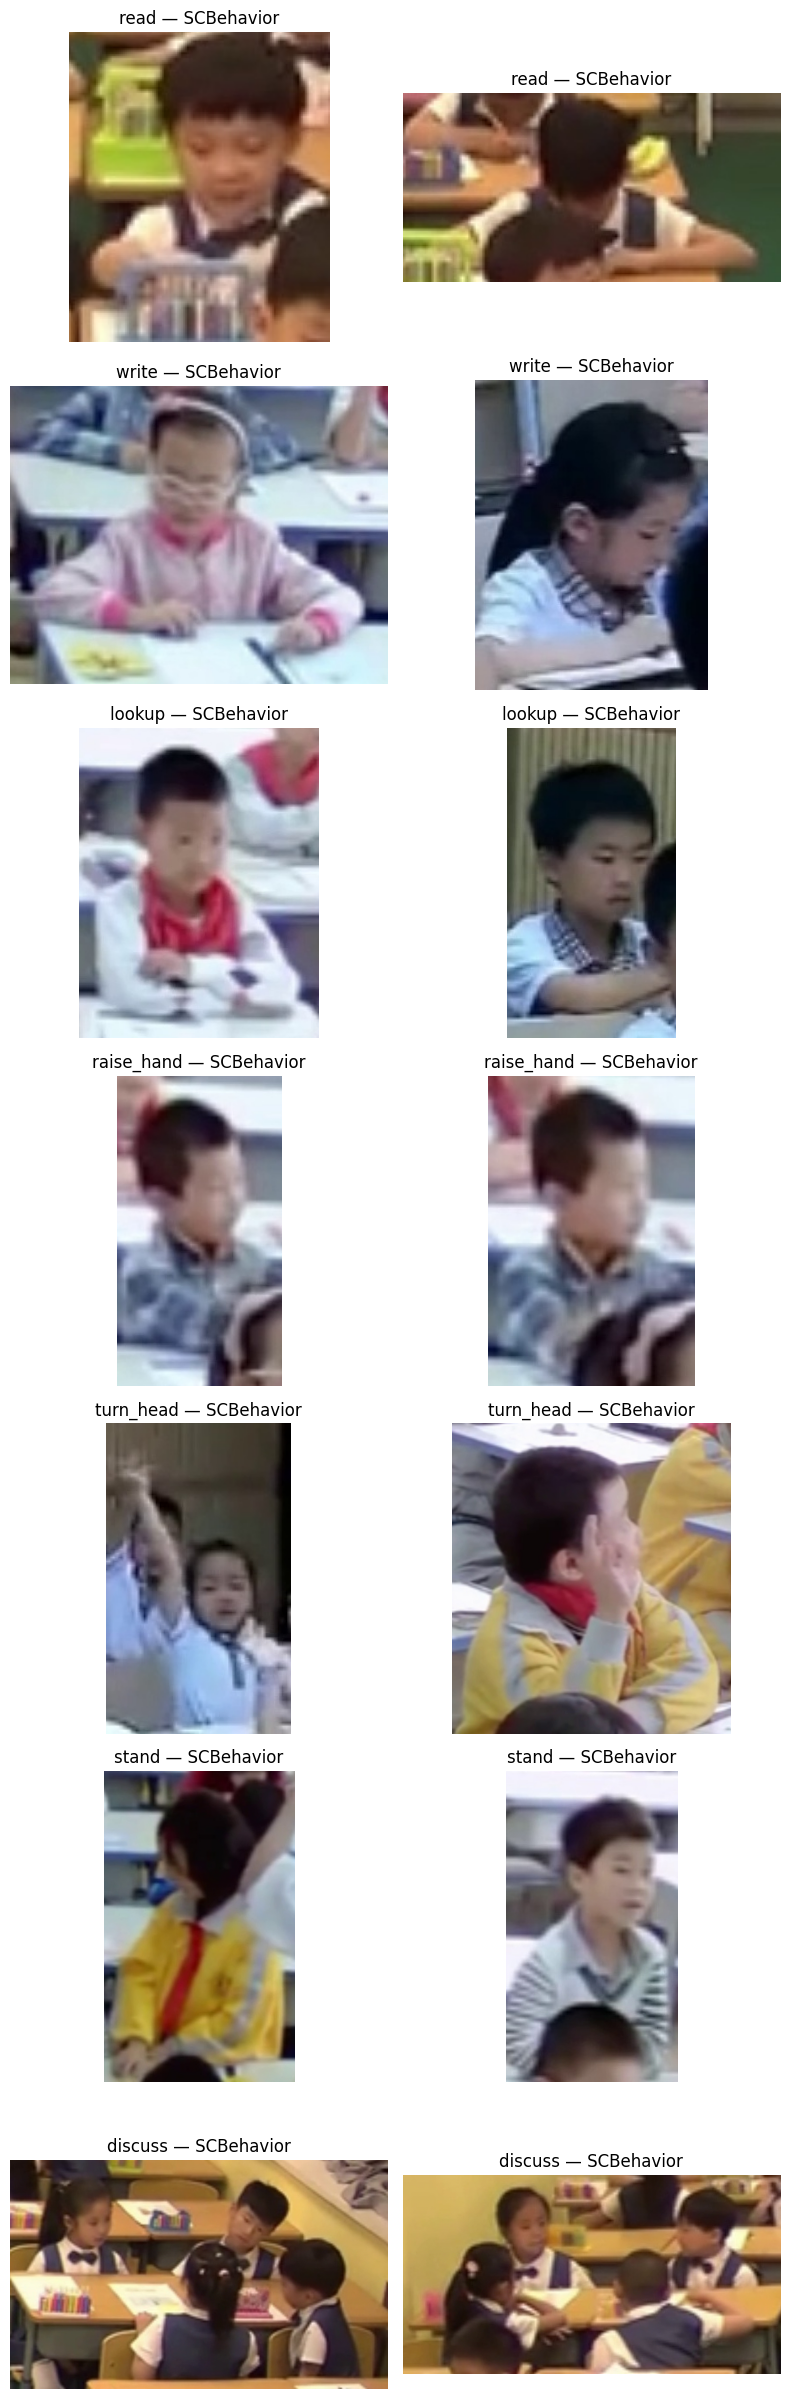

In [ ]:
def mostrar_muestras(
    dataframe: pd.DataFrame,
    muestras_por_clase: int = 2,
):
    filas = []

    for clase in CLASES:
        datos_clase = dataframe[
            dataframe["clase"] == clase
        ]

        if datos_clase.empty:
            continue

        filas.append(
            datos_clase.sample(
                n=min(
                    muestras_por_clase,
                    len(datos_clase),
                ),
                random_state=SEMILLA,
            )
        )

    muestras = pd.concat(
        filas,
        ignore_index=True,
    )

    columnas = muestras_por_clase
    filas_grafico = math.ceil(
        len(muestras) / columnas
    )

    plt.figure(
        figsize=(
            4 * columnas,
            3.5 * filas_grafico,
        )
    )

    for indice, fila in muestras.iterrows():
        imagen = cv2.imread(
            fila["imagen_path"]
        )

        imagen = cv2.cvtColor(
            imagen,
            cv2.COLOR_BGR2RGB,
        )

        plt.subplot(
            filas_grafico,
            columnas,
            indice + 1,
        )

        plt.imshow(imagen)
        plt.title(
            f"{fila['clase']} — {fila['dataset_origen']}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


mostrar_muestras(
    df_datos[
        df_datos["split"] == "train"
    ],
    muestras_por_clase=2,
)

# 17. Pipelines `tf.data`

In [ ]:
AUMENTO_DATOS = keras.Sequential(
    [
        keras.layers.RandomFlip("horizontal"),
        keras.layers.RandomRotation(0.04),
        keras.layers.RandomZoom(
            height_factor=(-0.08, 0.08),
            width_factor=(-0.08, 0.08),
        ),
        keras.layers.RandomTranslation(
            height_factor=0.04,
            width_factor=0.04,
        ),
        keras.layers.RandomContrast(0.12),
    ],
    name="aumento_datos",
)


def cargar_imagen(
    ruta,
    etiqueta,
    entrenamiento=False,
):
    contenido = tf.io.read_file(ruta)

    imagen = tf.io.decode_image(
        contenido,
        channels=3,
        expand_animations=False,
    )

    imagen.set_shape(
        [None, None, 3]
    )

    imagen = tf.image.resize_with_pad(
        imagen,
        TAMANO_IMAGEN[0],
        TAMANO_IMAGEN[1],
        method="bilinear",
    )

    imagen = tf.cast(
        imagen,
        tf.float32,
    )

    if entrenamiento:
        imagen = AUMENTO_DATOS(
            imagen,
            training=True,
        )

        imagen = tf.clip_by_value(
            imagen,
            0.0,
            255.0,
        )

    etiqueta = tf.cast(
        etiqueta,
        tf.int32,
    )

    return imagen, etiqueta


def crear_dataset(
    dataframe: pd.DataFrame,
    entrenamiento: bool,
):
    rutas = dataframe[
        "imagen_path"
    ].astype(str).to_numpy()

    etiquetas = dataframe[
        "label_id"
    ].astype(np.int32).to_numpy()

    dataset = tf.data.Dataset.from_tensor_slices(
        (rutas, etiquetas)
    )

    if entrenamiento:
        dataset = dataset.shuffle(
            buffer_size=min(
                len(dataframe),
                10000,
            ),
            seed=SEMILLA,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        lambda ruta, etiqueta: cargar_imagen(
            ruta,
            etiqueta,
            entrenamiento=entrenamiento,
        ),
        num_parallel_calls=AUTOTUNE,
    )

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False,
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


train_df = (
    df_datos[
        df_datos["split"] == "train"
    ]
    .sample(
        frac=1,
        random_state=SEMILLA,
    )
    .reset_index(drop=True)
)

val_df = (
    df_datos[
        df_datos["split"] == "val"
    ]
    .reset_index(drop=True)
)

test_df = (
    df_datos[
        df_datos["split"] == "test"
    ]
    .reset_index(drop=True)
)

train_ds = crear_dataset(
    train_df,
    entrenamiento=True,
)

val_ds = crear_dataset(
    val_df,
    entrenamiento=False,
)

test_ds = crear_dataset(
    test_df,
    entrenamiento=False,
)

for imagenes, etiquetas in train_ds.take(1):
    print("Imágenes:", imagenes.shape)
    print("Etiquetas:", etiquetas.shape)
    print(
        "Rango:",
        float(tf.reduce_min(imagenes)),
        float(tf.reduce_max(imagenes)),
    )

Imágenes: (32, 224, 224, 3)
Etiquetas: (32,)
Rango: 0.0 255.0


# 18. Pesos de clase

In [ ]:
conteos_train = (
    train_df["label_id"]
    .value_counts()
    .reindex(
        range(NUMERO_CLASES),
        fill_value=0,
    )
    .sort_index()
)

display(
    pd.DataFrame(
        {
            "clase": CLASES,
            "cantidad_train": conteos_train.values,
        }
    )
)

if (conteos_train == 0).any():
    raise RuntimeError(
        "No se puede entrenar porque una clase no tiene muestras."
    )

ratio_desbalance = (
    conteos_train.max()
    / conteos_train.min()
)

print("Ratio máximo/mínimo:", ratio_desbalance)

PESOS_CLASE = None

if (
    CONFIGURACION["entrenamiento"]["usar_pesos_clase"]
    and ratio_desbalance >= 1.5
):
    pesos = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(NUMERO_CLASES),
        y=train_df["label_id"].to_numpy(),
    )

    max_peso = float(
        CONFIGURACION["entrenamiento"][
            "max_peso_clase"
        ]
    )

    pesos = np.clip(
        pesos,
        0.5,
        max_peso,
    )

    PESOS_CLASE = {
        indice: float(peso)
        for indice, peso in enumerate(pesos)
    }

print("Pesos de clase:", PESOS_CLASE)

,clase,cantidad_train
0,read,422
1,write,716
2,lookup,3083
3,raise_hand,724
4,turn_head,467
5,stand,47
6,discuss,172


Ratio máximo/mínimo: 65.59574468085107
Pesos de clase: {0: 1.9062288422477995, 1: 1.1235035913806863, 2: 0.5, 3: 1.111089187056038, 4: 1.7225451208320588, 5: 3.0, 6: 3.0}


# 19. Construcción de arquitecturas

In [ ]:
def construir_modelo(
    arquitectura: str,
    numero_clases: int,
):
    entrada = keras.Input(
        shape=(
            TAMANO_IMAGEN[0],
            TAMANO_IMAGEN[1],
            3,
        ),
        name="imagen",
    )

    if arquitectura == "MobileNetV2":
        x = keras.layers.Rescaling(
            scale=1.0 / 127.5,
            offset=-1.0,
            name="normalizacion_mobilenetv2",
        )(entrada)

        base = keras.applications.MobileNetV2(
            include_top=False,
            weights="imagenet",
            input_shape=(
                TAMANO_IMAGEN[0],
                TAMANO_IMAGEN[1],
                3,
            ),
        )

        caracteristicas = base(
            x,
            training=False,
        )

    elif arquitectura == "MobileNetV3Small":
        x = keras.layers.Rescaling(
            scale=1.0 / 127.5,
            offset=-1.0,
            name="normalizacion_mobilenetv3",
        )(entrada)

        base = keras.applications.MobileNetV3Small(
            include_top=False,
            weights="imagenet",
            input_shape=(
                TAMANO_IMAGEN[0],
                TAMANO_IMAGEN[1],
                3,
            ),
            include_preprocessing=False,
        )

        caracteristicas = base(
            x,
            training=False,
        )

    elif arquitectura == "EfficientNetB0":
        base = keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=(
                TAMANO_IMAGEN[0],
                TAMANO_IMAGEN[1],
                3,
            ),
        )

        caracteristicas = base(
            entrada,
            training=False,
        )

    else:
        raise ValueError(
            f"Arquitectura no reconocida: {arquitectura}"
        )

    base.trainable = False

    x = keras.layers.GlobalAveragePooling2D(
        name="global_average_pooling",
    )(caracteristicas)

    x = keras.layers.Dropout(
        CONFIGURACION["entrenamiento"]["dropout"],
        name="dropout",
    )(x)

    salida = keras.layers.Dense(
        numero_clases,
        activation="softmax",
        dtype="float32",
        name="comportamiento",
    )(x)

    modelo = keras.Model(
        entrada,
        salida,
        name=f"modelo_comportamientos_{arquitectura}",
    )

    return modelo, base


def compilar_modelo(
    modelo,
    learning_rate,
):
    modelo.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate,
        ),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ],
    )


def configurar_fine_tuning(
    base,
    ultimas_capas: int,
):
    base.trainable = True

    for capa in base.layers[
        :-ultimas_capas
    ]:
        capa.trainable = False

    for capa in base.layers[
        -ultimas_capas:
    ]:
        if isinstance(
            capa,
            keras.layers.BatchNormalization,
        ):
            capa.trainable = False
        else:
            capa.trainable = True

# 20. Utilidades de evaluación

In [ ]:
def obtener_y_real(dataset):
    etiquetas = []

    for _, lote_etiquetas in dataset:
        etiquetas.append(
            lote_etiquetas.numpy()
        )

    return np.concatenate(
        etiquetas
    ).astype(np.int32)


def calcular_metricas(
    y_real,
    y_predicho,
):
    return {
        "accuracy": float(
            accuracy_score(
                y_real,
                y_predicho,
            )
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_real,
                y_predicho,
            )
        ),
        "precision_macro": float(
            precision_score(
                y_real,
                y_predicho,
                average="macro",
                zero_division=0,
            )
        ),
        "recall_macro": float(
            recall_score(
                y_real,
                y_predicho,
                average="macro",
                zero_division=0,
            )
        ),
        "f1_macro": float(
            f1_score(
                y_real,
                y_predicho,
                average="macro",
                zero_division=0,
            )
        ),
        "f1_weighted": float(
            f1_score(
                y_real,
                y_predicho,
                average="weighted",
                zero_division=0,
            )
        ),
        "mcc": float(
            matthews_corrcoef(
                y_real,
                y_predicho,
            )
        ),
    }


def evaluar_modelo_keras(
    modelo,
    dataset,
):
    y_real = obtener_y_real(
        dataset
    )

    probabilidades = modelo.predict(
        dataset,
        verbose=0,
    )

    y_predicho = np.argmax(
        probabilidades,
        axis=1,
    )

    metricas = calcular_metricas(
        y_real,
        y_predicho,
    )

    return metricas, y_real, y_predicho, probabilidades


def callbacks_entrenamiento(
    nombre: str,
    ruta_checkpoint: Path,
):
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=str(ruta_checkpoint),
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            mode="min",
            patience=CONFIGURACION[
                "entrenamiento"
            ]["paciencia"],
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            mode="min",
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            str(
                CARPETAS["metricas"]
                / f"historial_{nombre}.csv"
            ),
            append=False,
        ),
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.BackupAndRestore(
            backup_dir=str(
                CARPETAS["checkpoints"]
                / f"backup_{nombre}"
            ),
            delete_checkpoint=True,
        ),
    ]


def seleccionar_por_metricas(
    dataframe: pd.DataFrame,
):
    return (
        dataframe
        .sort_values(
            [
                "f1_macro",
                "mcc",
                "balanced_accuracy",
                "accuracy",
            ],
            ascending=[
                False,
                False,
                False,
                False,
            ],
        )
        .iloc[0]
    )

# 21. Comparación de arquitecturas

In [ ]:
RESULTADOS_ARQUITECTURAS = []

if CONFIGURACION["arquitecturas"]["comparar"]:
    arquitecturas = CONFIGURACION[
        "arquitecturas"
    ]["candidatas"]
else:
    arquitecturas = [
        CONFIGURACION[
            "arquitecturas"
        ]["predeterminada"]
    ]

for arquitectura in arquitecturas:
    print("\n" + "=" * 78)
    print("COMPARANDO:", arquitectura)
    print("=" * 78)

    keras.backend.clear_session()
    gc.collect()

    modelo_temporal, _ = construir_modelo(
        arquitectura,
        NUMERO_CLASES,
    )

    compilar_modelo(
        modelo_temporal,
        CONFIGURACION["entrenamiento"][
            "learning_rate"
        ],
    )

    modelo_temporal.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CONFIGURACION[
            "entrenamiento"
        ]["epocas_comparacion"],
        class_weight=PESOS_CLASE,
        verbose=1,
    )

    metricas_val, _, _, _ = evaluar_modelo_keras(
        modelo_temporal,
        val_ds,
    )

    RESULTADOS_ARQUITECTURAS.append(
        {
            "arquitectura": arquitectura,
            **metricas_val,
        }
    )

    del modelo_temporal
    gc.collect()

df_comparacion_arquitecturas = pd.DataFrame(
    RESULTADOS_ARQUITECTURAS
)

display(
    df_comparacion_arquitecturas.sort_values(
        [
            "f1_macro",
            "mcc",
            "balanced_accuracy",
        ],
        ascending=False,
    )
)

df_comparacion_arquitecturas.to_csv(
    CARPETAS["metricas"]
    / "comparacion_arquitecturas.csv",
    index=False,
)

fila_mejor_arquitectura = seleccionar_por_metricas(
    df_comparacion_arquitecturas
)

ARQUITECTURA_FINAL = fila_mejor_arquitectura[
    "arquitectura"
]

print("Arquitectura seleccionada:", ARQUITECTURA_FINAL)


COMPARANDO: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/4
176/176 ━━━━━━━━━━━━━━━━━━━━ 88s 384ms/step - accuracy: 0.5180 - loss: 1.3245 - val_accuracy: 0.6471 - val_loss: 0.9309
Epoch 2/4
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 239ms/step - accuracy: 0.6271 - loss: 0.9869 - val_accuracy: 0.6479 - val_loss: 0.9554
Epoch 3/4
176/176 ━━━━━━━━━━━━━━━━━━━━ 42s 235ms/step - accuracy: 0.6571 - loss: 0.8788 - val_accuracy: 0.6449 - val_loss: 0.9214
Epoch 4/4
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 230ms/step - accuracy: 0.6805 - loss: 0.8213 - val_accuracy: 0.7163 - val_loss: 0.7907

COMPARANDO: MobileNetV3Small
4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/4
176/176 ━━━━━━━━━━━━━━━━━━━━ 71s 321ms/step - accuracy: 0.4807 - loss: 1.4260 - val_accuracy: 0.6038 - val_loss: 1.1210
Epoch 2/4
176/176 ━━━━━━━━━━━━━━━━━━━━ 41s 230ms/step - accuracy: 0.5855 - loss: 1.1028 - val_accuracy: 0.5856 - val_loss: 1.0592
Epoch 3/4
176/176 ━━━━━━━━━━━━━━━━━━━━ 40s 228ms/step - accuracy: 0

,arquitectura,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc
2,EfficientNetB0,0.745247,0.738755,0.725008,0.738755,0.724351,0.735262,0.609314
0,MobileNetV2,0.716350,0.724476,0.688695,0.724476,0.694206,0.706204,0.576060
1,MobileNetV3Small,0.688973,0.600449,0.720712,0.600449,0.602170,0.679032,0.532266


Arquitectura seleccionada: EfficientNetB0


# 22. Entrenamiento inicial del modelo seleccionado

In [ ]:
keras.backend.clear_session()
gc.collect()

modelo_comportamientos, base_comportamientos = (
    construir_modelo(
        ARQUITECTURA_FINAL,
        NUMERO_CLASES,
    )
)

compilar_modelo(
    modelo_comportamientos,
    CONFIGURACION["entrenamiento"][
        "learning_rate"
    ],
)

RUTA_CHECKPOINT_CABEZA = (
    CARPETAS["checkpoints"]
    / "mejor_modelo_cabeza.keras"
)

historial_cabeza = modelo_comportamientos.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIGURACION[
        "entrenamiento"
    ]["epocas_cabeza"],
    class_weight=PESOS_CLASE,
    callbacks=callbacks_entrenamiento(
        "cabeza",
        RUTA_CHECKPOINT_CABEZA,
    ),
    verbose=1,
)

modelo_cabeza = keras.models.load_model(
    RUTA_CHECKPOINT_CABEZA,
    compile=False,
)

compilar_modelo(
    modelo_cabeza,
    CONFIGURACION["entrenamiento"][
        "learning_rate"
    ],
)

metricas_val_cabeza, _, _, _ = (
    evaluar_modelo_keras(
        modelo_cabeza,
        val_ds,
    )
)

print("Métricas de validación — cabeza congelada:")
print(metricas_val_cabeza)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5243 - loss: 1.4073
Epoch 1: val_loss improved from None to 0.87886, saving model to /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/checkpoints/mejor_modelo_cabeza.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/checkpoints/mejor_modelo_cabeza.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 82s 346ms/step - accuracy: 0.5974 - loss: 1.1891 - val_accuracy: 0.7171 - val_loss: 0.8789 - learning_rate: 0.0010
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.6634 - loss: 0.9302
Epoch 2: val_loss improved from 0.87886 to 0.78908, saving model to /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/checkpoints/mejor_modelo_cabeza.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/checkpo

# 23. Ajuste fino

In [ ]:
configurar_fine_tuning(
    base_comportamientos,
    ultimas_capas=CONFIGURACION[
        "entrenamiento"
    ]["ultimas_capas_entrenables"],
)

compilar_modelo(
    modelo_comportamientos,
    CONFIGURACION["entrenamiento"][
        "fine_tune_learning_rate"
    ],
)

RUTA_CHECKPOINT_FINE = (
    CARPETAS["checkpoints"]
    / "mejor_modelo_fine_tuning.keras"
)

epocas_cabeza_realizadas = len(
    historial_cabeza.history["loss"]
)

historial_fine = modelo_comportamientos.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=epocas_cabeza_realizadas,
    epochs=(
        epocas_cabeza_realizadas
        + CONFIGURACION[
            "entrenamiento"
        ]["epocas_fine_tuning"]
    ),
    class_weight=PESOS_CLASE,
    callbacks=callbacks_entrenamiento(
        "fine_tuning",
        RUTA_CHECKPOINT_FINE,
    ),
    verbose=1,
)

modelo_fine = keras.models.load_model(
    RUTA_CHECKPOINT_FINE,
    compile=False,
)

compilar_modelo(
    modelo_fine,
    CONFIGURACION["entrenamiento"][
        "fine_tune_learning_rate"
    ],
)

metricas_val_fine, _, _, _ = (
    evaluar_modelo_keras(
        modelo_fine,
        val_ds,
    )
)

df_comparacion_fases = pd.DataFrame(
    [
        {
            "fase": "cabeza_congelada",
            **metricas_val_cabeza,
        },
        {
            "fase": "fine_tuning",
            **metricas_val_fine,
        },
    ]
)

display(df_comparacion_fases)

fila_mejor_fase = seleccionar_por_metricas(
    df_comparacion_fases
)

FASE_FINAL = fila_mejor_fase["fase"]

if FASE_FINAL == "fine_tuning":
    modelo_final = modelo_fine
else:
    modelo_final = modelo_cabeza

print("Fase seleccionada:", FASE_FINAL)

Epoch 16/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.7378 - loss: 0.6461
Epoch 16: val_loss improved from None to 0.61697, saving model to /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/checkpoints/mejor_modelo_fine_tuning.keras

Epoch 16: finished saving model to /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/checkpoints/mejor_modelo_fine_tuning.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 91s 369ms/step - accuracy: 0.7455 - loss: 0.6341 - val_accuracy: 0.7833 - val_loss: 0.6170 - learning_rate: 2.0000e-05
Epoch 17/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7542 - loss: 0.6219
Epoch 17: val_loss improved from 0.61697 to 0.59464, saving model to /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/checkpoints/mejor_modelo_fine_tuning.keras

Epoch 17: finished saving model to /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Compo

,fase,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc
0,cabeza_congelada,0.771103,0.772184,0.756029,0.772184,0.755014,0.766175,0.647919
1,fine_tuning,0.817490,0.823789,0.811281,0.823789,0.816074,0.817238,0.721552


Fase seleccionada: fine_tuning


# 24. Curvas de entrenamiento

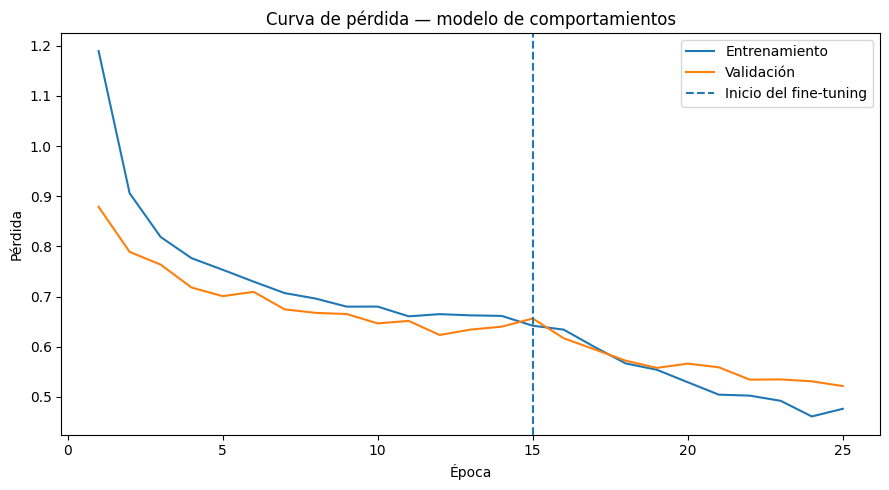

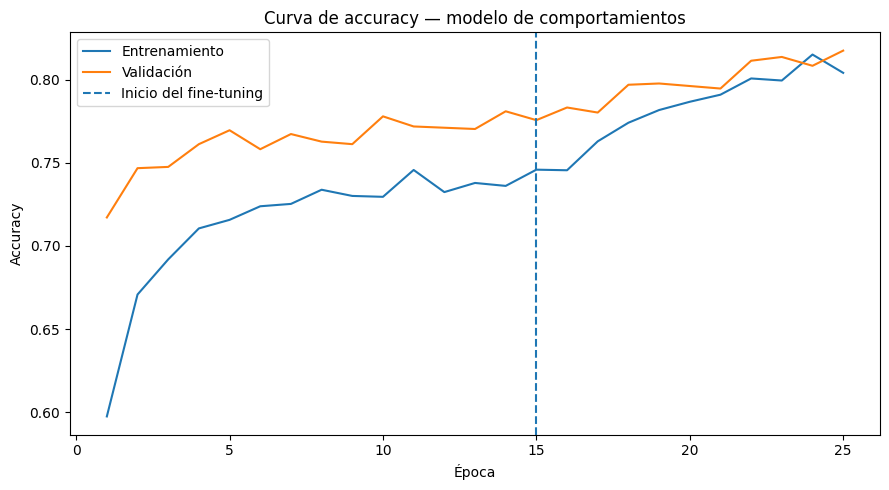

In [ ]:
historial_total = {}

for clave in set(
    historial_cabeza.history
) | set(
    historial_fine.history
):
    historial_total[clave] = (
        historial_cabeza.history.get(
            clave,
            [],
        )
        + historial_fine.history.get(
            clave,
            [],
        )
    )

df_historial = pd.DataFrame(
    historial_total
)

df_historial.to_csv(
    CARPETAS["metricas"]
    / "historial_entrenamiento_completo.csv",
    index=False,
)

plt.figure(figsize=(9, 5))
plt.plot(
    df_historial.index + 1,
    df_historial["loss"],
    label="Entrenamiento",
)

if "val_loss" in df_historial:
    plt.plot(
        df_historial.index + 1,
        df_historial["val_loss"],
        label="Validación",
    )

plt.axvline(
    len(historial_cabeza.history["loss"]),
    linestyle="--",
    label="Inicio del fine-tuning",
)

plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Curva de pérdida — modelo de comportamientos")
plt.legend()
plt.tight_layout()
plt.savefig(
    CARPETAS["graficos"]
    / "curva_perdida.png",
    dpi=200,
)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    df_historial.index + 1,
    df_historial["accuracy"],
    label="Entrenamiento",
)

if "val_accuracy" in df_historial:
    plt.plot(
        df_historial.index + 1,
        df_historial["val_accuracy"],
        label="Validación",
    )

plt.axvline(
    len(historial_cabeza.history["loss"]),
    linestyle="--",
    label="Inicio del fine-tuning",
)

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Curva de accuracy — modelo de comportamientos")
plt.legend()
plt.tight_layout()
plt.savefig(
    CARPETAS["graficos"]
    / "curva_accuracy.png",
    dpi=200,
)
plt.show()

# 25. Evaluación final en TensorFlow

RESULTADOS TENSORFLOW — MODELO DE COMPORTAMIENTOS
accuracy              : 0.7924
balanced_accuracy     : 0.8077
precision_macro       : 0.7663
recall_macro          : 0.8077
f1_macro              : 0.7853
f1_weighted           : 0.7951
mcc                   : 0.6647


,precision,recall,f1-score,support
read,0.739130,0.879310,0.803150,58.000000
write,0.551471,0.547445,0.549451,137.000000
lookup,0.898618,0.857771,0.877719,682.000000
raise_hand,0.547945,0.625000,0.583942,128.000000
turn_head,0.727273,0.744186,0.735632,86.000000
stand,0.900000,1.000000,0.947368,9.000000
discuss,1.000000,1.000000,1.000000,37.000000
accuracy,0.792436,0.792436,0.792436,0.792436
macro avg,0.766348,0.807673,0.785323,1137.000000
weighted avg,0.799526,0.792436,0.795072,1137.000000


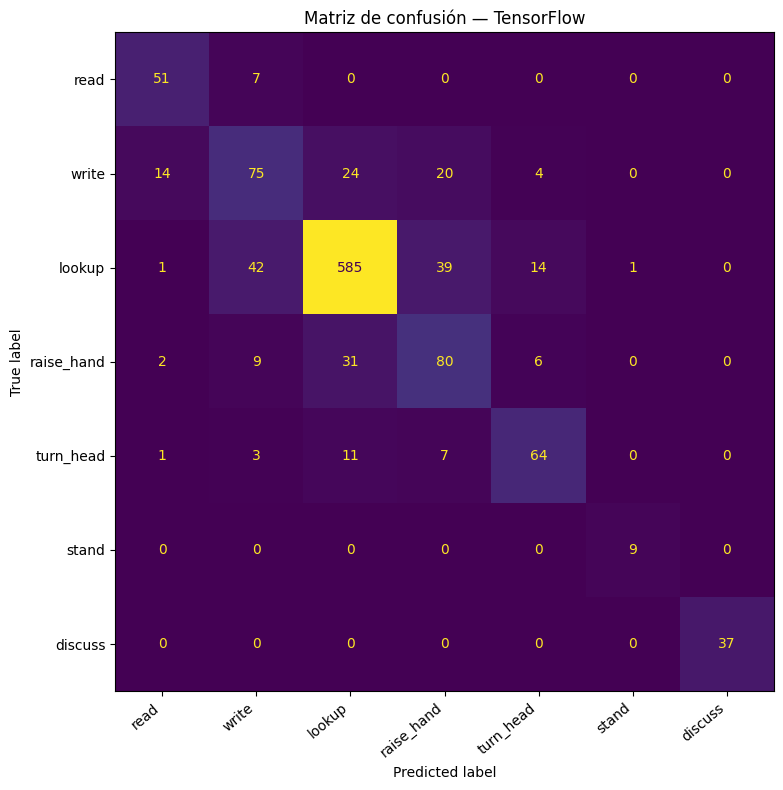

In [ ]:
metricas_tensorflow, y_test, y_pred_tf, probabilidades_tf = (
    evaluar_modelo_keras(
        modelo_final,
        test_ds,
    )
)

print("=" * 78)
print("RESULTADOS TENSORFLOW — MODELO DE COMPORTAMIENTOS")
print("=" * 78)

for clave, valor in metricas_tensorflow.items():
    print(f"{clave:<22}: {valor:.4f}")

reporte_por_clase = classification_report(
    y_test,
    y_pred_tf,
    labels=list(range(NUMERO_CLASES)),
    target_names=CLASES,
    zero_division=0,
    output_dict=True,
)

df_reporte_por_clase = pd.DataFrame(
    reporte_por_clase
).T

display(df_reporte_por_clase)

df_reporte_por_clase.to_csv(
    CARPETAS["metricas"]
    / "reporte_por_clase_tensorflow.csv"
)

matriz = confusion_matrix(
    y_test,
    y_pred_tf,
    labels=list(range(NUMERO_CLASES)),
)

figura, eje = plt.subplots(
    figsize=(9, 8)
)

visualizador = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=CLASES,
)

visualizador.plot(
    ax=eje,
    values_format="d",
    colorbar=False,
)

plt.xticks(rotation=40, ha="right")
plt.title("Matriz de confusión — TensorFlow")
plt.tight_layout()
plt.savefig(
    CARPETAS["graficos"]
    / "matriz_confusion_tensorflow.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# 26. Decisión de aceptabilidad

In [ ]:
def clasificar_aceptabilidad(metricas):
    cumple = (
        metricas["f1_macro"]
        >= CONFIGURACION["evaluacion"][
            "f1_macro_aceptable"
        ]
        and metricas["mcc"]
        >= CONFIGURACION["evaluacion"][
            "mcc_aceptable"
        ]
        and metricas["balanced_accuracy"]
        >= CONFIGURACION["evaluacion"][
            "balanced_accuracy_aceptable"
        ]
    )

    return (
        "ACEPTABLE"
        if cumple
        else "NO ACEPTABLE"
    )


ESTADO_TENSORFLOW = clasificar_aceptabilidad(
    metricas_tensorflow
)

print("Estado del modelo TensorFlow:", ESTADO_TENSORFLOW)

print(
    "La decisión prioriza F1 macro, MCC y Balanced Accuracy; "
    "no se basa únicamente en Accuracy."
)

Estado del modelo TensorFlow: ACEPTABLE
La decisión prioriza F1 macro, MCC y Balanced Accuracy; no se basa únicamente en Accuracy.


# 27. Guardado del modelo TensorFlow

In [ ]:
RUTA_MODELO_KERAS = (
    CARPETAS["modelos"]
    / "modelo_comportamientos_final.keras"
)

modelo_final.save(
    RUTA_MODELO_KERAS
)

guardar_json(
    {
        "nombre": "modelo_comportamientos",
        "arquitectura": ARQUITECTURA_FINAL,
        "fase_seleccionada": FASE_FINAL,
        "tipo": "clasificacion_multiclase",
        "entrada": [
            TAMANO_IMAGEN[0],
            TAMANO_IMAGEN[1],
            3,
        ],
        "rango_entrada": "0 a 255 en float32",
        "clases": {
            indice: clase
            for indice, clase in enumerate(CLASES)
        },
        "datasets": [
            "SCBehavior",
            "SCB-Dataset5" if USAR_SCB5 else None,
        ],
        "metricas_test_tensorflow": metricas_tensorflow,
        "estado": ESTADO_TENSORFLOW,
    },
    CARPETAS["reportes"]
    / "metadata_tensorflow.json",
)

print("Modelo TensorFlow guardado en:")
print(RUTA_MODELO_KERAS)

Modelo TensorFlow guardado en:
/content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/modelo_comportamientos_final.keras


# 28. Conversión a TensorFlow Lite

In [ ]:
RUTAS_VARIANTES = {}


def guardar_modelo_tflite(
    contenido: bytes,
    nombre: str,
):
    ruta = (
        CARPETAS["tflite"]
        / f"modelo_comportamientos_{nombre}.tflite"
    )

    ruta.write_bytes(contenido)
    RUTAS_VARIANTES[nombre] = ruta

    print(
        f"{nombre:<10}: "
        f"{ruta} — {listar_tamano(ruta):.3f} MB"
    )


conversor_fp32 = tf.lite.TFLiteConverter.from_keras_model(
    modelo_final
)

modelo_fp32 = conversor_fp32.convert()

guardar_modelo_tflite(
    modelo_fp32,
    "fp32",
)


conversor_dynamic = tf.lite.TFLiteConverter.from_keras_model(
    modelo_final
)

conversor_dynamic.optimizations = [
    tf.lite.Optimize.DEFAULT
]

modelo_dynamic = conversor_dynamic.convert()

guardar_modelo_tflite(
    modelo_dynamic,
    "dynamic",
)


conversor_float16 = tf.lite.TFLiteConverter.from_keras_model(
    modelo_final
)

conversor_float16.optimizations = [
    tf.lite.Optimize.DEFAULT
]

conversor_float16.target_spec.supported_types = [
    tf.float16
]

modelo_float16 = conversor_float16.convert()

guardar_modelo_tflite(
    modelo_float16,
    "float16",
)

Saved artifact at '/tmp/tmprt2qc9pj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='imagen')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  138924315315280: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138924315317584: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138924279411728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138924279400400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138924279399248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138924279400208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138924279400592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138923725544848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138923725547536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138923725545808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13

# 29. Cuantización INT8

In [ ]:
def conjunto_representativo():
    contador = 0

    for lote_imagenes, _ in train_ds:
        for imagen in lote_imagenes:
            yield [
                np.expand_dims(
                    imagen.numpy().astype(
                        np.float32
                    ),
                    axis=0,
                )
            ]

            contador += 1

            if contador >= 300:
                return


try:
    conversor_int8 = tf.lite.TFLiteConverter.from_keras_model(
        modelo_final
    )

    conversor_int8.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    conversor_int8.representative_dataset = (
        conjunto_representativo
    )

    conversor_int8.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]

    conversor_int8.inference_input_type = tf.int8
    conversor_int8.inference_output_type = tf.int8

    modelo_int8 = conversor_int8.convert()

    guardar_modelo_tflite(
        modelo_int8,
        "int8",
    )

except Exception as error:
    print(
        "No se pudo generar INT8. "
        "Las otras variantes continúan disponibles."
    )
    print(error)

Saved artifact at '/tmp/tmphuyaew8a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='imagen')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  138924315315280: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138924315317584: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  138924279411728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138924279400400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138924279399248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138924279400208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138924279400592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138923725544848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138923725547536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138923725545808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


int8      : /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/modelos/tflite/modelo_comportamientos_int8.tflite — 4.693 MB


# 30. Ejecutor TensorFlow Lite

In [ ]:
def cuantizar_entrada(
    arreglo,
    detalle,
):
    dtype = detalle["dtype"]

    if dtype in (
        np.int8,
        np.uint8,
    ):
        escala, cero = detalle[
            "quantization"
        ]

        if escala == 0:
            raise RuntimeError(
                "La escala de cuantización de entrada es cero."
            )

        arreglo = np.round(
            arreglo / escala + cero
        )

        limites = np.iinfo(dtype)

        arreglo = np.clip(
            arreglo,
            limites.min,
            limites.max,
        )

        return arreglo.astype(dtype)

    return arreglo.astype(dtype)


def descuantizar_salida(
    arreglo,
    detalle,
):
    dtype = detalle["dtype"]

    if dtype in (
        np.int8,
        np.uint8,
    ):
        escala, cero = detalle[
            "quantization"
        ]

        return (
            arreglo.astype(np.float32)
            - cero
        ) * escala

    return arreglo.astype(np.float32)


class EjecutorTFLite:
    def __init__(self, ruta_modelo: Path):
        self.ruta_modelo = Path(ruta_modelo)

        self.interprete = tf.lite.Interpreter(
            model_path=str(self.ruta_modelo),
            num_threads=max(
                1,
                min(
                    4,
                    os.cpu_count() or 1,
                ),
            ),
        )

        self.interprete.allocate_tensors()

        self.entrada = self.interprete.get_input_details()[0]
        self.salida = self.interprete.get_output_details()[0]

    def predecir(self, imagen):
        arreglo = np.expand_dims(
            imagen,
            axis=0,
        ).astype(np.float32)

        arreglo = cuantizar_entrada(
            arreglo,
            self.entrada,
        )

        self.interprete.set_tensor(
            self.entrada["index"],
            arreglo,
        )

        self.interprete.invoke()

        salida = self.interprete.get_tensor(
            self.salida["index"]
        )

        salida = descuantizar_salida(
            salida,
            self.salida,
        )

        return salida[0]

# 31. Evaluación predictiva y computacional de TensorFlow Lite

In [ ]:
def iterar_imagenes_dataset(
    dataset,
):
    for lote_imagenes, lote_etiquetas in dataset:
        imagenes = lote_imagenes.numpy()
        etiquetas = lote_etiquetas.numpy()

        for imagen, etiqueta in zip(
            imagenes,
            etiquetas,
        ):
            yield (
                imagen.astype(np.float32),
                int(etiqueta),
            )


def evaluar_variante_tflite(
    nombre,
    ruta_modelo,
    dataset,
):
    ejecutor = EjecutorTFLite(
        ruta_modelo
    )

    y_real = []
    y_predicho = []

    for imagen, etiqueta in iterar_imagenes_dataset(
        dataset
    ):
        probabilidades = ejecutor.predecir(
            imagen
        )

        y_real.append(etiqueta)

        y_predicho.append(
            int(np.argmax(probabilidades))
        )

    metricas = calcular_metricas(
        np.asarray(y_real),
        np.asarray(y_predicho),
    )

    return {
        "formato": "TFLite",
        "variante": nombre,
        "tamano_mb": listar_tamano(
            Path(ruta_modelo)
        ),
        **metricas,
    }


def benchmark_tflite(
    ruta_modelo,
    dataset,
    max_muestras,
):
    ejecutor = EjecutorTFLite(
        ruta_modelo
    )

    proceso = psutil.Process(
        os.getpid()
    )

    cpu_inicial = proceso.cpu_times()
    tiempo_inicial = time.perf_counter()

    latencias = []
    memorias = []
    contador = 0

    for imagen, _ in iterar_imagenes_dataset(
        dataset
    ):
        inicio = time.perf_counter()

        ejecutor.predecir(
            imagen
        )

        latencias.append(
            (
                time.perf_counter()
                - inicio
            ) * 1000
        )

        memorias.append(
            proceso.memory_info().rss
            / (1024 ** 2)
        )

        contador += 1

        if contador >= max_muestras:
            break

    tiempo_total = (
        time.perf_counter()
        - tiempo_inicial
    )

    cpu_final = proceso.cpu_times()

    segundos_cpu = (
        cpu_final.user
        + cpu_final.system
        - cpu_inicial.user
        - cpu_inicial.system
    )

    cpu_promedio_pct = (
        100
        * segundos_cpu
        / max(
            tiempo_total
            * (os.cpu_count() or 1),
            1e-9,
        )
    )

    latencias = np.asarray(
        latencias,
        dtype=np.float64,
    )

    return {
        "muestras_benchmark": contador,
        "latencia_media_ms": float(
            np.mean(latencias)
        ),
        "latencia_mediana_ms": float(
            np.median(latencias)
        ),
        "latencia_p95_ms": float(
            np.percentile(
                latencias,
                95,
            )
        ),
        "fps": float(
            contador / tiempo_total
        ),
        "fps_teorico_inferencia": float(
            1000 / np.mean(latencias)
        ),
        "cpu_promedio_pct": float(
            cpu_promedio_pct
        ),
        "ram_promedio_mb": float(
            np.mean(memorias)
        ),
        "ram_maxima_mb": float(
            np.max(memorias)
        ),
    }


RESULTADOS_TFLITE = []

for nombre, ruta in RUTAS_VARIANTES.items():
    print("\nEvaluando:", nombre)

    resultado = evaluar_variante_tflite(
        nombre,
        ruta,
        test_ds,
    )

    rendimiento = benchmark_tflite(
        ruta,
        test_ds,
        max_muestras=CONFIGURACION[
            "evaluacion"
        ]["muestras_benchmark"],
    )

    resultado.update(
        rendimiento
    )

    RESULTADOS_TFLITE.append(
        resultado
    )

df_resultados_tflite = pd.DataFrame(
    RESULTADOS_TFLITE
)

display(
    df_resultados_tflite.sort_values(
        [
            "f1_macro",
            "mcc",
            "balanced_accuracy",
        ],
        ascending=False,
    )
)

df_resultados_tflite.to_csv(
    CARPETAS["metricas"]
    / "resultados_tflite.csv",
    index=False,
)


Evaluando: fp32


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Evaluando: dynamic


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Evaluando: float16


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Evaluando: int8


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


,formato,variante,tamano_mb,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,muestras_benchmark,latencia_media_ms,latencia_mediana_ms,latencia_p95_ms,fps,fps_teorico_inferencia,cpu_promedio_pct,ram_promedio_mb,ram_maxima_mb
0,TFLite,fp32,15.331017,0.792436,0.807673,0.766348,0.807673,0.785323,0.795072,0.664675,300,9.276546,9.444718,11.099756,100.034997,107.798741,47.850074,6354.415937,6354.933594
2,TFLite,float16,7.728584,0.790677,0.807254,0.764604,0.807254,0.784178,0.793504,0.662401,300,9.188970,9.198477,11.247651,99.020372,108.826130,46.539575,6416.702513,6420.132812
1,TFLite,dynamic,4.349243,0.784521,0.806737,0.760427,0.806737,0.780973,0.788261,0.654953,300,21.807949,20.410086,31.180081,44.376827,45.854839,53.011818,6364.880911,6365.109375
3,TFLite,int8,4.693481,0.595427,0.705886,0.536478,0.705886,0.568234,0.622287,0.455235,300,8.787496,8.800972,10.660928,105.911206,113.798057,47.968950,6368.946862,6368.980469


# 32. Benchmark del modelo TensorFlow

In [ ]:
def benchmark_tensorflow(
    modelo,
    dataset,
    max_muestras,
):
    proceso = psutil.Process(
        os.getpid()
    )

    cpu_inicial = proceso.cpu_times()
    tiempo_inicial = time.perf_counter()

    latencias = []
    memorias = []
    contador = 0

    for imagen, _ in iterar_imagenes_dataset(
        dataset
    ):
        entrada = np.expand_dims(
            imagen,
            axis=0,
        ).astype(np.float32)

        inicio = time.perf_counter()

        modelo(
            entrada,
            training=False,
        ).numpy()

        latencias.append(
            (
                time.perf_counter()
                - inicio
            ) * 1000
        )

        memorias.append(
            proceso.memory_info().rss
            / (1024 ** 2)
        )

        contador += 1

        if contador >= max_muestras:
            break

    tiempo_total = (
        time.perf_counter()
        - tiempo_inicial
    )

    cpu_final = proceso.cpu_times()

    segundos_cpu = (
        cpu_final.user
        + cpu_final.system
        - cpu_inicial.user
        - cpu_inicial.system
    )

    cpu_promedio_pct = (
        100
        * segundos_cpu
        / max(
            tiempo_total
            * (os.cpu_count() or 1),
            1e-9,
        )
    )

    latencias = np.asarray(
        latencias,
        dtype=np.float64,
    )

    return {
        "muestras_benchmark": contador,
        "latencia_media_ms": float(
            np.mean(latencias)
        ),
        "latencia_mediana_ms": float(
            np.median(latencias)
        ),
        "latencia_p95_ms": float(
            np.percentile(
                latencias,
                95,
            )
        ),
        "fps": float(
            contador / tiempo_total
        ),
        "fps_teorico_inferencia": float(
            1000 / np.mean(latencias)
        ),
        "cpu_promedio_pct": float(
            cpu_promedio_pct
        ),
        "ram_promedio_mb": float(
            np.mean(memorias)
        ),
        "ram_maxima_mb": float(
            np.max(memorias)
        ),
    }


rendimiento_tensorflow = benchmark_tensorflow(
    modelo_final,
    test_ds,
    max_muestras=CONFIGURACION[
        "evaluacion"
    ]["muestras_benchmark"],
)

resultado_tensorflow = {
    "formato": "TensorFlow",
    "variante": "keras",
    "tamano_mb": listar_tamano(
        RUTA_MODELO_KERAS
    ),
    **metricas_tensorflow,
    **rendimiento_tensorflow,
}

df_comparacion_formatos = pd.concat(
    [
        pd.DataFrame(
            [resultado_tensorflow]
        ),
        df_resultados_tflite,
    ],
    ignore_index=True,
)

display(df_comparacion_formatos)

df_comparacion_formatos.to_csv(
    CARPETAS["metricas"]
    / "comparacion_tensorflow_tflite.csv",
    index=False,
)

,formato,variante,tamano_mb,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,mcc,muestras_benchmark,latencia_media_ms,latencia_mediana_ms,latencia_p95_ms,fps,fps_teorico_inferencia,cpu_promedio_pct,ram_promedio_mb,ram_maxima_mb
0,TensorFlow,keras,16.279938,0.792436,0.807673,0.766348,0.807673,0.785323,0.795072,0.664675,300,314.713827,308.181207,338.960019,3.167975,3.177490,12.584779,6377.115859,6377.480469
1,TFLite,fp32,15.331017,0.792436,0.807673,0.766348,0.807673,0.785323,0.795072,0.664675,300,9.276546,9.444718,11.099756,100.034997,107.798741,47.850074,6354.415937,6354.933594
2,TFLite,dynamic,4.349243,0.784521,0.806737,0.760427,0.806737,0.780973,0.788261,0.654953,300,21.807949,20.410086,31.180081,44.376827,45.854839,53.011818,6364.880911,6365.109375
3,TFLite,float16,7.728584,0.790677,0.807254,0.764604,0.807254,0.784178,0.793504,0.662401,300,9.188970,9.198477,11.247651,99.020372,108.826130,46.539575,6416.702513,6420.132812
4,TFLite,int8,4.693481,0.595427,0.705886,0.536478,0.705886,0.568234,0.622287,0.455235,300,8.787496,8.800972,10.660928,105.911206,113.798057,47.968950,6368.946862,6368.980469


# 33. Selección de la mejor variante TensorFlow Lite

In [ ]:
perdida_maxima = float(
    CONFIGURACION["evaluacion"][
        "perdida_maxima_tflite"
    ]
)

candidatas = df_resultados_tflite.copy()

candidatas["caida_f1"] = (
    metricas_tensorflow["f1_macro"]
    - candidatas["f1_macro"]
)

candidatas["caida_mcc"] = (
    metricas_tensorflow["mcc"]
    - candidatas["mcc"]
)

candidatas["caida_balanced_accuracy"] = (
    metricas_tensorflow[
        "balanced_accuracy"
    ]
    - candidatas["balanced_accuracy"]
)

aceptables = candidatas[
    (candidatas["caida_f1"] <= perdida_maxima)
    & (candidatas["caida_mcc"] <= perdida_maxima)
    & (
        candidatas[
            "caida_balanced_accuracy"
        ]
        <= perdida_maxima
    )
].copy()

if aceptables.empty:
    print(
        "Ninguna variante conserva simultáneamente "
        "las tres métricas dentro de la tolerancia. "
        "Se priorizará el desempeño predictivo."
    )

    mejor_tflite = seleccionar_por_metricas(
        candidatas
    )
else:
    mejor_tflite = (
        aceptables
        .sort_values(
            [
                "tamano_mb",
                "latencia_media_ms",
                "f1_macro",
                "mcc",
            ],
            ascending=[
                True,
                True,
                False,
                False,
            ],
        )
        .iloc[0]
    )

VARIANTE_FINAL_TFLITE = mejor_tflite[
    "variante"
]

RUTA_TFLITE_FINAL_ORIGEN = RUTAS_VARIANTES[
    VARIANTE_FINAL_TFLITE
]

RUTA_TFLITE_FINAL = (
    CARPETAS["exportacion"]
    / "modelo_comportamientos_final.tflite"
)

shutil.copy2(
    RUTA_TFLITE_FINAL_ORIGEN,
    RUTA_TFLITE_FINAL,
)

print("Variante seleccionada:", VARIANTE_FINAL_TFLITE)
print("Modelo final:", RUTA_TFLITE_FINAL)
print(mejor_tflite.to_dict())

Variante seleccionada: dynamic
Modelo final: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/exportacion_final/modelo_comportamientos_final.tflite
{'formato': 'TFLite', 'variante': 'dynamic', 'tamano_mb': 4.3492431640625, 'accuracy': 0.7845206684256816, 'balanced_accuracy': 0.8067366227228475, 'precision_macro': 0.7604268233275285, 'recall_macro': 0.8067366227228475, 'f1_macro': 0.7809727549070338, 'f1_weighted': 0.7882605689343717, 'mcc': 0.654953245833948, 'muestras_benchmark': 300, 'latencia_media_ms': 21.807949293338424, 'latencia_mediana_ms': 20.410085999856165, 'latencia_p95_ms': 31.180081250136038, 'fps': 44.37682692101911, 'fps_teorico_inferencia': 45.854838827301634, 'cpu_promedio_pct': 53.0118178260666, 'ram_promedio_mb': 6364.880911458334, 'ram_maxima_mb': 6365.109375, 'caida_f1': 0.004350358865440551, 'caida_mcc': 0.009722198928998838, 'caida_balanced_accuracy': 0.0009366498215430674}


# 34. Tabla final según la operacionalización

In [ ]:
estado_final = clasificar_aceptabilidad(
    mejor_tflite.to_dict()
)

tabla_operacionalizacion = pd.DataFrame(
    [
        {
            "dimension": "Desempeño del modelo TensorFlow Lite",
            "indicador": "Accuracy",
            "subindicador": "Proporción global de predicciones correctas",
            "escala": "Razón (%)",
            "resultado": 100 * mejor_tflite["accuracy"],
        },
        {
            "dimension": "Desempeño del modelo TensorFlow Lite",
            "indicador": "Precisión macro",
            "subindicador": "Promedio de precisión entre las clases",
            "escala": "Razón (%)",
            "resultado": 100 * mejor_tflite["precision_macro"],
        },
        {
            "dimension": "Desempeño del modelo TensorFlow Lite",
            "indicador": "Recall macro",
            "subindicador": "Promedio de sensibilidad entre las clases",
            "escala": "Razón (%)",
            "resultado": 100 * mejor_tflite["recall_macro"],
        },
        {
            "dimension": "Desempeño del modelo TensorFlow Lite",
            "indicador": "F1-Score macro",
            "subindicador": "Balance global entre precisión y recall",
            "escala": "Razón (%)",
            "resultado": 100 * mejor_tflite["f1_macro"],
        },
        {
            "dimension": "Desempeño del modelo TensorFlow Lite",
            "indicador": "MCC",
            "subindicador": "Correlación global ante desbalance",
            "escala": "Intervalo (-1 a 1)",
            "resultado": mejor_tflite["mcc"],
        },
        {
            "dimension": "Rendimiento computacional",
            "indicador": "Tiempo de inferencia",
            "subindicador": "Tiempo promedio por imagen",
            "escala": "Razón (ms)",
            "resultado": mejor_tflite["latencia_media_ms"],
        },
        {
            "dimension": "Rendimiento computacional",
            "indicador": "Velocidad de procesamiento",
            "subindicador": "Imágenes procesadas por segundo",
            "escala": "Razón (FPS)",
            "resultado": mejor_tflite["fps"],
        },
        {
            "dimension": "Rendimiento computacional",
            "indicador": "Uso del procesador",
            "subindicador": "Utilización media del CPU",
            "escala": "Razón (%)",
            "resultado": mejor_tflite["cpu_promedio_pct"],
        },
        {
            "dimension": "Rendimiento computacional",
            "indicador": "Uso de memoria RAM",
            "subindicador": "Memoria RAM durante la inferencia",
            "escala": "Razón (MB)",
            "resultado": mejor_tflite["ram_promedio_mb"],
        },
        {
            "dimension": "Rendimiento computacional",
            "indicador": "Tamaño del modelo",
            "subindicador": "Espacio ocupado por el archivo TFLite",
            "escala": "Razón (MB)",
            "resultado": mejor_tflite["tamano_mb"],
        },
    ]
)

display(tabla_operacionalizacion)

print("Estado final:", estado_final)

tabla_operacionalizacion.to_csv(
    CARPETAS["reportes"]
    / "tabla_operacionalizacion.csv",
    index=False,
)

,dimension,indicador,subindicador,escala,resultado
0,Desempeño del modelo TensorFlow Lite,Accuracy,Proporción global de predicciones correctas,Razón (%),78.452067
1,Desempeño del modelo TensorFlow Lite,Precisión macro,Promedio de precisión entre las clases,Razón (%),76.042682
2,Desempeño del modelo TensorFlow Lite,Recall macro,Promedio de sensibilidad entre las clases,Razón (%),80.673662
3,Desempeño del modelo TensorFlow Lite,F1-Score macro,Balance global entre precisión y recall,Razón (%),78.097275
4,Desempeño del modelo TensorFlow Lite,MCC,Correlación global ante desbalance,Intervalo (-1 a 1),0.654953
5,Rendimiento computacional,Tiempo de inferencia,Tiempo promedio por imagen,Razón (ms),21.807949
6,Rendimiento computacional,Velocidad de procesamiento,Imágenes procesadas por segundo,Razón (FPS),44.376827
7,Rendimiento computacional,Uso del procesador,Utilización media del CPU,Razón (%),53.011818
8,Rendimiento computacional,Uso de memoria RAM,Memoria RAM durante la inferencia,Razón (MB),6364.880911
9,Rendimiento computacional,Tamaño del modelo,Espacio ocupado por el archivo TFLite,Razón (MB),4.349243


Estado final: ACEPTABLE


# 35. Exportación final

In [ ]:
RUTA_LABELS = (
    CARPETAS["exportacion"]
    / "modelo_comportamientos_labels.json"
)

RUTA_METADATA = (
    CARPETAS["exportacion"]
    / "modelo_comportamientos_metadata.json"
)

guardar_json(
    {
        "clases": {
            indice: clase
            for indice, clase in enumerate(CLASES)
        }
    },
    RUTA_LABELS,
)

metadata_final = {
    "nombre": "modelo_comportamientos",
    "fecha_exportacion": datetime.now().isoformat(),
    "arquitectura": ARQUITECTURA_FINAL,
    "fase_seleccionada": FASE_FINAL,
    "variante_tflite": VARIANTE_FINAL_TFLITE,
    "entrada": [
        TAMANO_IMAGEN[0],
        TAMANO_IMAGEN[1],
        3,
    ],
    "rango_entrada": "0 a 255",
    "tipo_entrada": "float32 o cuantizada según variante",
    "salida": "probabilidades softmax para siete clases",
    "clases": {
        indice: clase
        for indice, clase in enumerate(CLASES)
    },
    "datasets": {
        "principal": "SCBehavior",
        "complementario": (
            "SCB-Dataset5"
            if USAR_SCB5
            else None
        ),
        "scb5_solo_entrenamiento": True,
    },
    "metricas_tensorflow": metricas_tensorflow,
    "metricas_tflite_final": mejor_tflite.to_dict(),
    "estado": estado_final,
}

guardar_json(
    metadata_final,
    RUTA_METADATA,
)

RUTA_EXCEL = (
    CARPETAS["exportacion"]
    / "Resultados_Modelo_Comportamiento.xlsx"
)

with pd.ExcelWriter(
    RUTA_EXCEL,
    engine="openpyxl",
) as escritor:
    tabla_soporte.reset_index().to_excel(
        escritor,
        sheet_name="Soporte",
        index=False,
    )

    df_comparacion_arquitecturas.to_excel(
        escritor,
        sheet_name="Arquitecturas",
        index=False,
    )

    df_comparacion_fases.to_excel(
        escritor,
        sheet_name="Fases",
        index=False,
    )

    df_reporte_por_clase.reset_index().to_excel(
        escritor,
        sheet_name="Metricas_por_clase",
        index=False,
    )

    df_comparacion_formatos.to_excel(
        escritor,
        sheet_name="TensorFlow_TFLite",
        index=False,
    )

    tabla_operacionalizacion.to_excel(
        escritor,
        sheet_name="Operacionalizacion",
        index=False,
    )

lineas_readme = [
    "MODELO DE COMPORTAMIENTO ESTUDIANTIL",
    "====================================",
    "",
    "Archivo principal:",
    "- modelo_comportamientos_final.tflite",
    "",
    "Clases:",
]

lineas_readme.extend(
    [
        f"- {indice}: {clase}"
        for indice, clase in enumerate(CLASES)
    ]
)

lineas_readme.extend(
    [
        "",
        "Arquitectura:",
        f"- {ARQUITECTURA_FINAL}",
        "",
        "Fase seleccionada:",
        f"- {FASE_FINAL}",
        "",
        "Variante TFLite:",
        f"- {VARIANTE_FINAL_TFLITE}",
        "",
        "Estado:",
        f"- {estado_final}",
        "",
        (
            "Este modelo clasifica recortes individuales de estudiantes. "
            "La detección de personas, el seguimiento por ID y la lectura "
            "de video con OpenCV deben implementarse en el sistema."
        ),
    ]
)

(
    CARPETAS["exportacion"]
    / "README.txt"
).write_text(
    "\n".join(lineas_readme),
    encoding="utf-8",
)

RUTA_ZIP_FINAL = Path(
    shutil.make_archive(
        str(
            RUTA_PROYECTO
            / "Paquete_Modelo_Comportamiento_TFLite"
        ),
        "zip",
        root_dir=str(
            CARPETAS["exportacion"]
        ),
    )
)

print("=" * 78)
print("EXPORTACIÓN COMPLETADA")
print("=" * 78)
print("Carpeta:", CARPETAS["exportacion"])
print("Modelo:", RUTA_TFLITE_FINAL)
print("Labels:", RUTA_LABELS)
print("Metadata:", RUTA_METADATA)
print("Excel:", RUTA_EXCEL)
print("ZIP:", RUTA_ZIP_FINAL)

EXPORTACIÓN COMPLETADA
Carpeta: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/exportacion_final
Modelo: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/exportacion_final/modelo_comportamientos_final.tflite
Labels: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/exportacion_final/modelo_comportamientos_labels.json
Metadata: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/exportacion_final/modelo_comportamientos_metadata.json
Excel: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/exportacion_final/Resultados_Modelo_Comportamiento.xlsx
ZIP: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/Paquete_Modelo_Comportamiento_TFLite.zip


# 36. Prueba de inferencia con una imagen

Imagen: /content/drive/MyDrive/Proyecto_Comportamiento_Estudiantil_Modelo_Comportamiento/datasets/processed/recortes/SCBehavior/test/lookup/1fd774f568bd2787ed745fe0.jpg
Clase real: lookup
Clase predicha: lookup
Confianza: 0.7067033052444458


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


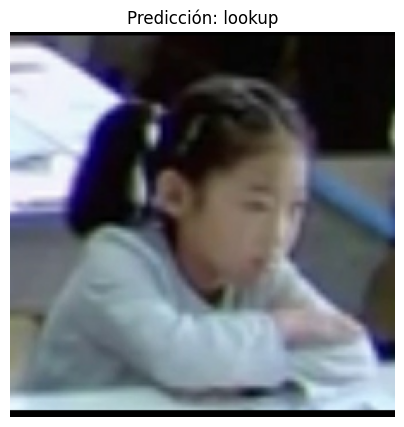

,clase,probabilidad
2,lookup,0.706703
3,raise_hand,0.194172
1,write,0.080404
4,turn_head,0.017180
0,read,0.001084
6,discuss,0.000308
5,stand,0.000150


In [ ]:
def preparar_imagen_desde_archivo(
    ruta_imagen: str,
):
    contenido = tf.io.read_file(
        ruta_imagen
    )

    imagen = tf.io.decode_image(
        contenido,
        channels=3,
        expand_animations=False,
    )

    imagen = tf.image.resize_with_pad(
        imagen,
        TAMANO_IMAGEN[0],
        TAMANO_IMAGEN[1],
    )

    return tf.cast(
        imagen,
        tf.float32,
    ).numpy()


ruta_prueba = test_df.iloc[0][
    "imagen_path"
]

imagen_prueba = preparar_imagen_desde_archivo(
    ruta_prueba
)

ejecutor_final = EjecutorTFLite(
    RUTA_TFLITE_FINAL
)

probabilidades = ejecutor_final.predecir(
    imagen_prueba
)

indice_predicho = int(
    np.argmax(probabilidades)
)

print("Imagen:", ruta_prueba)
print("Clase real:", test_df.iloc[0]["clase"])
print("Clase predicha:", CLASES[indice_predicho])
print("Confianza:", float(probabilidades[indice_predicho]))

plt.figure(figsize=(5, 5))
plt.imshow(
    imagen_prueba.astype(np.uint8)
)
plt.title(
    f"Predicción: {CLASES[indice_predicho]}"
)
plt.axis("off")
plt.show()

display(
    pd.DataFrame(
        {
            "clase": CLASES,
            "probabilidad": probabilidades,
        }
    ).sort_values(
        "probabilidad",
        ascending=False,
    )
)

# 37. Uso posterior en el sistema

El cuaderno entrega un clasificador de recortes individuales. En la aplicación final, el flujo recomendado será:

```text
Video de clase
→ OpenCV lee los fotogramas
→ un detector localiza a los estudiantes
→ un rastreador conserva un ID por estudiante
→ se recorta cada estudiante
→ modelo_comportamientos_final.tflite
→ read / write / lookup / raise_hand / turn_head / stand / discuss
→ agregación temporal e informe
```

El entrenamiento realizado aquí no identifica por sí solo a cada estudiante ni procesa directamente un video completo. Esas funciones corresponden al módulo de integración con OpenCV, detector de personas y seguimiento.